# Streamflow Modeling and Prediction

This notebook develops predictive models to examine how glacier retreat and climate variability influence late-summer streamflow in the North Fork Nooksack River basin (Washington, USA).

Processed datasets generated in previous notebooks are integrated into a unified hydrologic dataset containing glacier area, climate variables, and observed streamflow. This dataset is then used to perform exploratory analysis, construct hydrologically meaningful features, and train machine learning models to predict melt-season discharge.

The analysis focuses on understanding how short-term climate forcing (temperature and precipitation) and long-term glacier change contribute to streamflow variability during the late-summer melt season.

## Objectives
1. Merge glacier area, climate variables, and streamflow observations into a unified hydrologic modeling dataset.

2. Perform exploratory analysis to examine relationships between glacier change, climate forcing, and discharge.

3. Engineer predictive features including lagged climate variables and hydrologic memory.

4. Train and compare two modeling approaches:
    - Multiple Linear Regression (MLR) as an interpretable baseline model
    - Random Forest as a nonlinear machine learning model

5. Evaluate model performance using hydrologic metrics including NSE, KGE, RMSE, MAE, and Percent Bias.

## Data Sources
- Glacier area dataset derived from Landsat imagery (GEE)
- Climate variables from PRISM ANd daily dataset
- Streamflow observations from USGS NWIS Gauge 12205000

Input Files: 
`data/glacier.csv`, 
`data/climate_variables.csv`,
`data/streamflow.csv`

Output:
`data/merged_model_dataset.csv`

## Modeling Workflow

1. Data Integration
2. Exploratory Analysis
3. Feature Engineering
4. Model Development
5. Model Evaluation

# Environment Setup

In [1]:
# import libraries
# core 
import numpy as np
import pandas as pd
import sys
import os

sys.path.append(os.path.abspath('..')) 

from src.modeling_utils import (
    prepare_data, 
    train_predict_model, 
    tune_rf_model,
    evaluate, 
    get_full_report,
    nse, 
    kge, 
    pbias
)

# visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# statistics
import pymannkendall as mk
from scipy import stats
from scipy.stats import normaltest, linregress, wilcoxon
from sklearn.feature_selection import mutual_info_regression
from statsmodels.stats.outliers_influence import variance_inflation_factor

# time series
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import ccf

# machine learning
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Data Integration


## Load and merge processed datasets 
Merge annual glacier area, and daily climate and streamflow datasets on date and year

In [2]:
# load datasets
glacier = pd.read_csv("../data/glacier_area.csv")
climate = pd.read_csv("../data/climate_variables.csv")
streamflow = pd.read_csv("../data/streamflow.csv")

# merge climate and streamflow
df = pd.merge(
    streamflow[['date','year','q_cms','q_7d_roll_cms']],
    climate,
    on=['date','year'],
    how='inner'
)

# add glacier area
df = pd.merge(
    df,
    glacier[['year','glacier_area_km2','glacier_5_moving_avg']],
    on='year',
    how='left'
)

# 2. Exploratory Data Analysis

## Dataset Overview

In [3]:
# explore data
print('Data info:')
display(df.info())
print('\nStatistical analysis:')
display(df.describe().T)
print('\nNuls:')
display(df.isnull().sum())

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2501 entries, 0 to 2500
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  2501 non-null   object 
 1   year                  2501 non-null   int64  
 2   q_cms                 2501 non-null   float64
 3   q_7d_roll_cms         2501 non-null   float64
 4   ppt                   2501 non-null   float64
 5   tmean                 2501 non-null   float64
 6   date_label            2501 non-null   object 
 7   plot_index            2501 non-null   int64  
 8   glacier_area_km2      2501 non-null   float64
 9   glacier_5_moving_avg  2501 non-null   float64
dtypes: float64(6), int64(2), object(2)
memory usage: 195.5+ KB


None


Statistical analysis:


,count,mean,std,min,25%,50%,75%,max
year,2501.0,2004.000000,11.834526,1984.000000,1994.000000,2004.000000,2014.000000,2024.000000
q_cms,2501.0,18.700455,10.559092,4.898806,12.431075,16.310477,21.350867,105.904832
q_7d_roll_cms,2501.0,19.213878,8.497514,5.986981,13.357439,17.394606,22.483539,63.915063
ppt,2501.0,5.427307,14.846056,0.000000,0.000000,0.000000,2.560050,213.259400
tmean,2501.0,8.827267,4.960315,-4.354300,5.027802,8.746554,12.633050,21.698943
plot_index,2501.0,243.268293,17.615913,213.000000,228.000000,243.000000,259.000000,274.000000
glacier_area_km2,2501.0,4.896976,0.540265,3.282594,4.576846,4.984044,5.319175,5.934645
glacier_5_moving_avg,2501.0,4.893920,0.328466,3.960288,4.794285,4.972737,5.109703,5.380085



Nuls:


date                    0
year                    0
q_cms                   0
q_7d_roll_cms           0
ppt                     0
tmean                   0
date_label              0
plot_index              0
glacier_area_km2        0
glacier_5_moving_avg    0
dtype: int64

## Distribution Characteristics

### Distribution Shape and Skewness

Analysis:

- Streamflow (`q_cms`) exhibits strong positive skewness (2.93), indicating that most observations correspond to relatively low or moderate discharge values, while a smaller number of high-flow events produce a long right tail.

- The 7-day rolling mean discharge (`q_7d_roll_cms`) reduces the degree of skewness (1.54) relative to daily streamflow, reflecting the smoothing effect of temporal aggregation. Rolling averages dampen short-lived peaks and reduce the influence of extreme events, resulting in a more symmetric distribution.

- Precipitation (`ppt`) displays the strongest skewness (4.99), which is expected because precipitation events are intermittent and highly variable. Most days experience little or no rainfall, while occasional storm events produce large values, leading to a highly right-skewed distribution.

- Mean air temperature (`tmean`) is approximately symmetric (skewness ≈ 0), suggesting a relatively balanced distribution of temperature values during the study period. Despite the near-zero skewness, the normality test still rejects the null hypothesis of normality, likely due to the large sample size and subtle deviations from a Gaussian distribution.

- Glacier area (`glacier_area_km2`) and its 5-year moving average show moderate negative skewness (-0.80 and -1.43, respectively). This reflects the long-term decline in glacier extent over the study period.

- The D’Agostino-Pearson normality test rejects the null hypothesis of normality for all variables (p < 0.05). However, this result is expected given the large dataset size, where even minor deviations from normality can produce statistically significant results.

Implications for Modeling

- The strong right skew observed in streamflow and precipitation suggests that log transformations may improve model performance by stabilizing variance and reducing the influence of extreme values. 

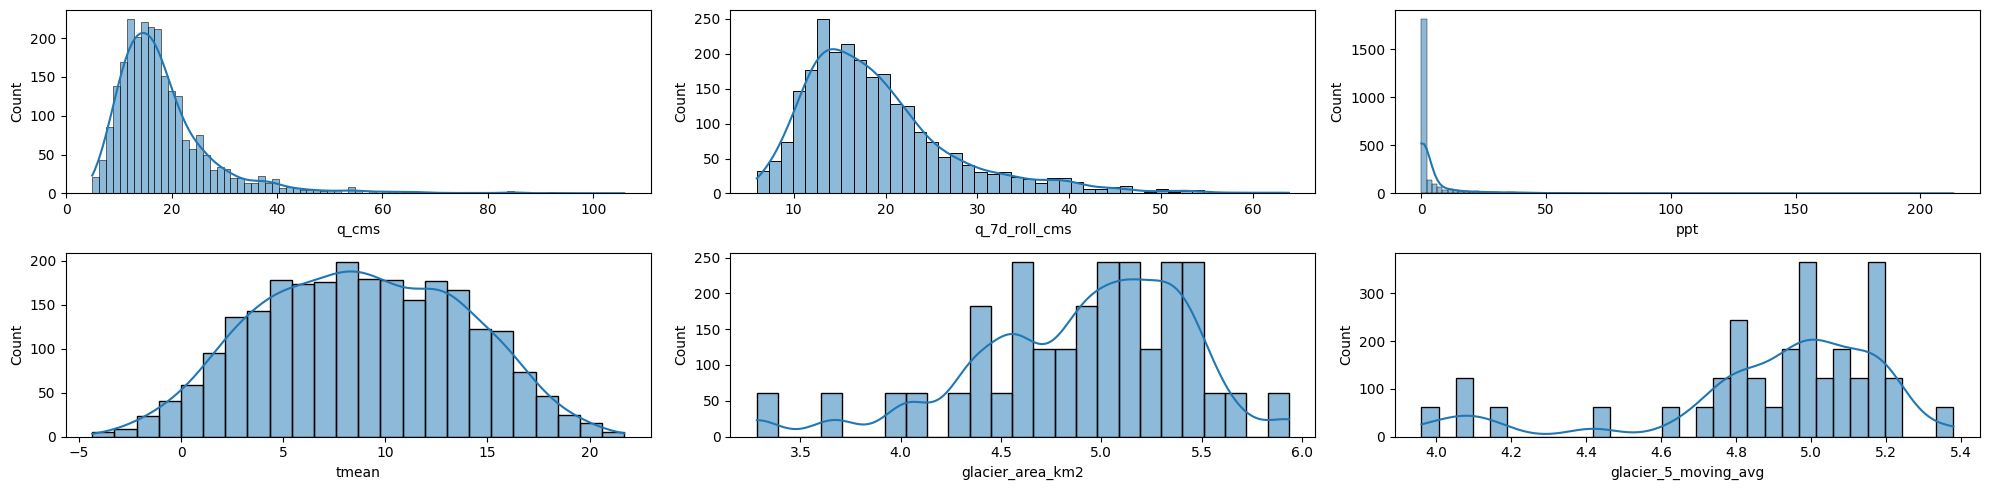

In [4]:
# check distributions of variables
vars_to_check = ['q_cms', 'q_7d_roll_cms', 'ppt', 'tmean', 'glacier_area_km2', 'glacier_5_moving_avg']

# function to plot distribution
def plot_distribution(df, variables):
    fig, axes = plt.subplots(2, 3, figsize=(20,5))
    axes = axes.flatten()

    for i,var in enumerate(variables):
        sns.histplot(df[var], kde=True, ax=axes[i])

    plt.tight_layout()

plot_distribution(df, vars_to_check)

In [5]:
# create distribution summary as a list of dictionaries
dist_stats = []
for var in vars_to_check:
    # D'Agostino-Pearson test for normality
    stat, p = normaltest(df[var])
    dist_stats.append({
        "Variable": var,
        "Skewness": df[var].skew(),
        "Normality P-Value": f"{p:.3e}",
        "Normally Dist?": "Yes" if p > 0.05 else "No"
    })

# display summary
df_dist_summary = pd.DataFrame(dist_stats).set_index("Variable")
display(df_dist_summary)

,Skewness,Normality P-Value,Normally Dist?
Variable,,,
q_cms,2.926005,0.000e+00,No
q_7d_roll_cms,1.537205,1.430e-159,No
ppt,4.986480,0.000e+00,No
tmean,-0.000793,5.581e-27,No
glacier_area_km2,-0.803312,1.080e-52,No
glacier_5_moving_avg,-1.429629,1.274e-126,No


### ECDF and Outlier Assessment

Empirical cumulative distribution functions (ECDFs) provide an alternative view of variable distributions by showing the proportion of observations below a given value. This highlights differences in distribution shape and the prevalence of extreme events.

Log transformations are applied here only for visualization to better compare distribution shapes. Permanent transformations for modeling are performed later during feature engineering.


Analysis of ECDFs and boxplots:
- Heavy precipitation events and high discharge values are rare, appearing in the upper tails of the distributions.

- Both precipitation and late-summer discharge are strongly right-skewed, with rare, high-magnitude events appearing in the upper tails. This is consistent with the skewness values reported in the previous section.

- Because both variables are non-normal and contain extreme values, log transformations must be applied before modeling. Additionally, predictive models should be robust to occasional extremes to avoid biasing results toward common low-to-moderate events.

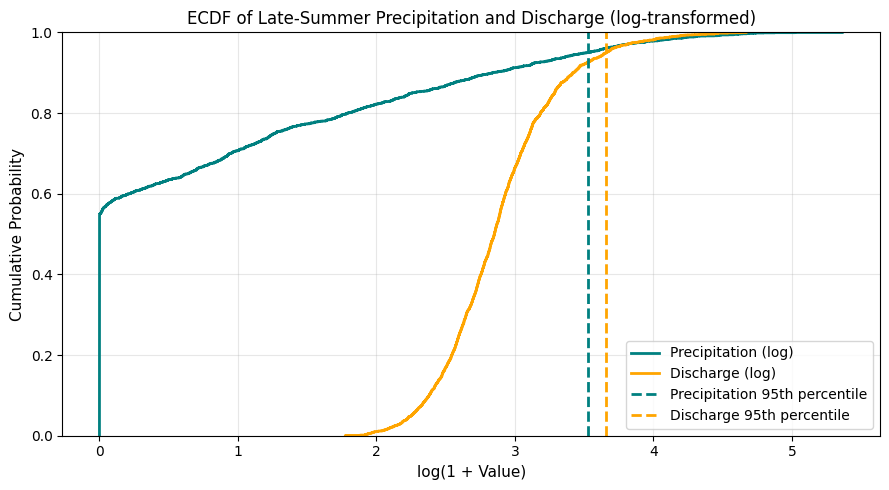

In [6]:
# ecdf plot

# compute 95th percentiles
ppt_95 = df['ppt'].quantile(0.95)
q_95 = df['q_cms'].quantile(0.95)

# log-transform for plotting
ppt_log = np.log1p(df['ppt'])
q_log = np.log1p(df['q_cms'])
ppt_95_log = np.log1p(ppt_95)
q_95_log = np.log1p(q_95)

plt.figure(figsize=(9,5))

# ECDFs
sns.ecdfplot(ppt_log, label='Precipitation (log)', color='teal', linewidth=2)
sns.ecdfplot(q_log, label='Discharge (log)', color='orange', linewidth=2)

# 95th percentile markers
plt.axvline(np.log1p(ppt_95), color='teal', linestyle='--', lw=2, label='Precipitation 95th percentile')
plt.axvline(np.log1p(q_95), color='orange', linestyle='--', lw=2, label='Discharge 95th percentile')

plt.title('ECDF of Late-Summer Precipitation and Discharge (log-transformed)', fontsize=12)
plt.xlabel('log(1 + Value)', fontsize=11)
plt.ylabel('Cumulative Probability', fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

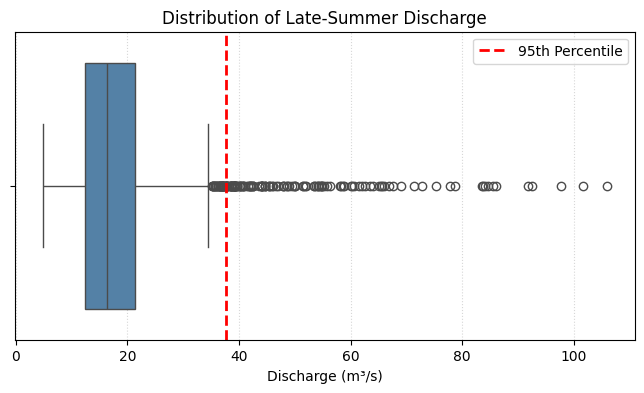

In [7]:
# discharge outlier analysis
plt.figure(figsize=(8,4))
sns.boxplot(x=df['q_cms'], color='steelblue')

# calculate 95th percentile
qcms_95 = df['q_cms'].quantile(0.95)

# add 95th percentile line
plt.axvline(qcms_95, color='red', linestyle='--', lw=2, label='95th Percentile')

plt.title('Distribution of Late-Summer Discharge')
plt.xlabel('Discharge (m³/s)')
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.legend()
plt.show()

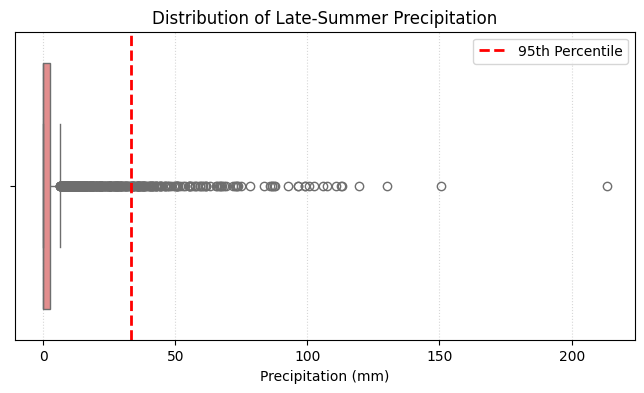

In [8]:
# precipitation outlier analysis
plt.figure(figsize=(8,4))
sns.boxplot(x=df['ppt'], color='lightcoral')

# calculate 95th percentile
ppt_95 = df['ppt'].quantile(0.95)

# add 95th percentile line
plt.axvline(ppt_95, color='red', linestyle='--', lw=2, label='95th Percentile')

plt.title('Distribution of Late-Summer Precipitation')
plt.xlabel('Precipitation (mm)')
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.legend()
plt.show()

## Hydrological Characteristics

### Flow Duration Curve



The Flow Duration Curve (FDC) plots discharge on a log scale against the percentage of time the flow is equaled or exceeded. This curve provides a compact summary of flow variability, highlighting typical, low, and high flows during the late-summer melt season.

Analysis: 
- 5th percentile: 37.66 - high flows exceeded only 5% of the time.

- 50th percentile (median): 16.31 - typical late-summer discharge.

- 95th percentile: 8.50 - low flows exceeded 95% of the time.

- The FDC shows a steep decline from high to low flows, indicating a highly skewed distribution characteristic of melt-season streams.

- Rare high flows are relatively short-lived, while low flows dominate much of the late-summer period.

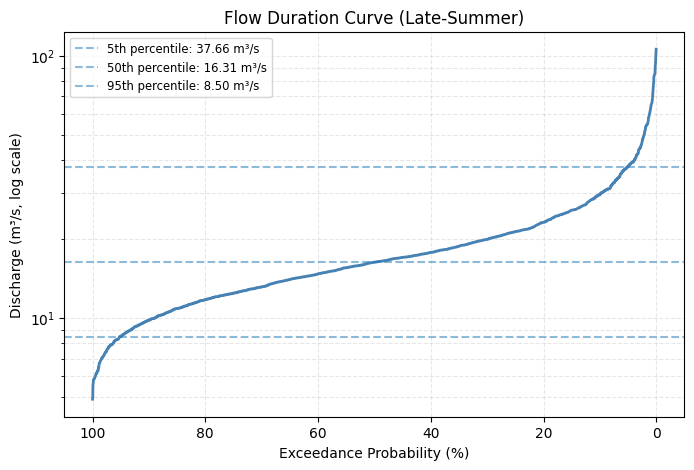

In [9]:
# plot flow duration curve

# sort q_cms from highest to lowest
q_sorted = np.sort(df['q_cms'])[::-1]

# create exceedance probability %
exceedance = np.arange(1, len(q_sorted)+1)/len(q_sorted) * 100

plt.figure(figsize=(8,5))
plt.plot(exceedance, q_sorted, color='steelblue', lw=2)

# log scale for y-axis
plt.yscale('log')

plt.xlabel("Exceedance Probability (%)")
plt.ylabel("Discharge (m³/s, log scale)")
plt.title("Flow Duration Curve (Late-Summer)")
plt.grid(True, which='both', linestyle='--', alpha=0.3)

# invert x-axis to show high flows on left
plt.gca().invert_xaxis()

# key percentiles
percentiles = [5, 50, 95]
for p in percentiles:
    q_val = np.percentile(df['q_cms'], 100-p)
    plt.axhline(q_val, linestyle='--', alpha=0.5, label=f'{p}th percentile: {q_val:.2f} m³/s')

plt.legend(fontsize='small')
plt.show()

### Seasonal Hydrograph

Analysis:
- Late-summer discharge decreases steadily from about 26 m³/s at the beginning of August to roughly 19 m³/s by the end of September.

- Spikes in variability between August 20 and August 30 suggest short-term, high-flow events.

- Late September exhibits considerable variability as flows drop to low levels, where small differences in melt or precipitation have a proportionally larger impact. 

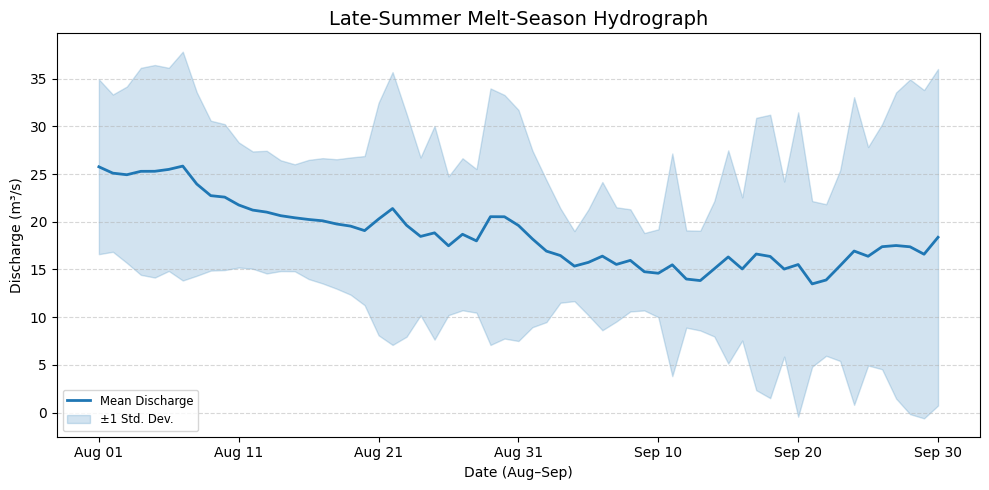

In [10]:
# compute seasonal day (0 = Aug 1)
df['season_day'] = df.groupby('year').cumcount()

# aggregate mean and std by season day
seasonal_profile = df.groupby('season_day')['q_cms'].agg(['mean', 'std'])

plt.figure(figsize=(10,5))

# plot mean hydrograph
plt.plot(seasonal_profile.index, seasonal_profile['mean'], 
         color='#1f77b4', lw=2, label='Mean Discharge')

# shade 1 std 
plt.fill_between(seasonal_profile.index,
                 seasonal_profile['mean'] - seasonal_profile['std'],
                 seasonal_profile['mean'] + seasonal_profile['std'],
                 color='#1f77b4', alpha=0.2, label='±1 Std. Dev.')

tick_days = [0, 10, 20, 30, 40, 50, 60]
tick_labels = pd.date_range('2000-08-01', periods=61).strftime('%b %d')[tick_days]  # dummy year for labels
plt.xticks(tick_days, tick_labels)

plt.xlabel('Date (Aug–Sep)')
plt.ylabel('Discharge (m³/s)')
plt.title('Late-Summer Melt-Season Hydrograph', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(fontsize='small')
plt.tight_layout()
plt.show()

### Streamflow Autocorrelation

Analysis:
- The autocorrelation function (ACF) shows strong positive autocorrelation at short lags, indicating that today’s discharge is strongly influenced by flows in preceding days.

- Specifically, lag 1 has an autocorrelation of ~0.75 and lag 2 remains above 0.50, highlighting the immediate temporal dependence.

- This confirms that daily streamflow is not independent, justifying the inclusion of lagged discharge features in predictive models.

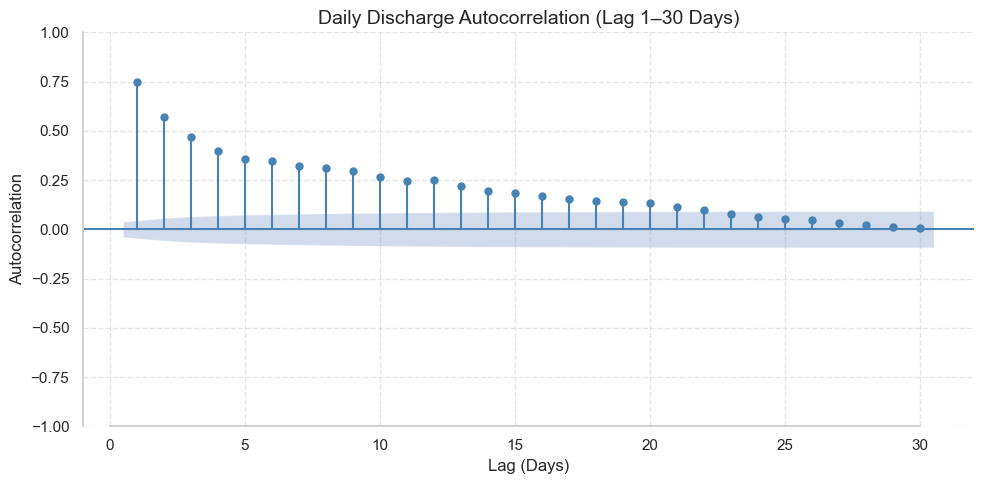

In [11]:
# visualize ACF in target variable

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,5))
plot_acf(df['q_cms'], lags=30, ax=plt.gca(),
         color='steelblue',
         vlines_kwargs={'colors': 'steelblue', 'linewidths': 1.5},
         zero=False,
         markerfacecolor='steelblue', markeredgecolor='steelblue')

plt.title("Daily Discharge Autocorrelation (Lag 1–30 Days)", fontsize=14)
plt.xlabel("Lag (Days)", fontsize=12)
plt.ylabel("Autocorrelation", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
sns.despine(trim=True)
plt.tight_layout()
plt.show()

## Long-Term Hydrologic Trends

### Trend Detection (Mann-Kendall Test)

The Mann–Kendall test is applied to annual mean streamflow to detect monotonic trends over time. This non-parametric test is robust to outliers and does not require normally distributed data.

Analysis:
- There is no statistically significant tren in annual mean late-summer discharge (p-value = 0.831).

- Kendall’s Tau is very close to zero (-0.024), further confirming absence of a monotonic trend.

- Sen’s slope is slightly negative (-0.0091 m³/s per year), suggesting a negligible decrease in flow over the study period.

- Overall, this indicates that late-summer discharge in the North Fork Nooksack River basin has remained relatively stable over the historical record, despite glacier retreat and climate variability.

In [12]:
# Mann-Kendall test
mk_res = mk.original_test(df.groupby('year')['q_cms'].mean())

# convert object attributes to a dictionary
mk_summary = pd.DataFrame({
    "Metric": ["Trend", "P-Value", "Tau", "Sen's Slope"],
    "Value": [mk_res.trend, f"{mk_res.p:.4f}", f"{mk_res.Tau:.4f}", f"{mk_res.slope:.4f}"]
})

display(mk_summary)

,Metric,Value
0,Trend,no trend
1,P-Value,0.8310
2,Tau,-0.0244
3,Sen's Slope,-0.0091


### Glacier and Streamflow Trends

To visualize how glacier retreat corresponds with long-term changes
in streamflow, annual mean discharge and glacier area are plotted
together. 

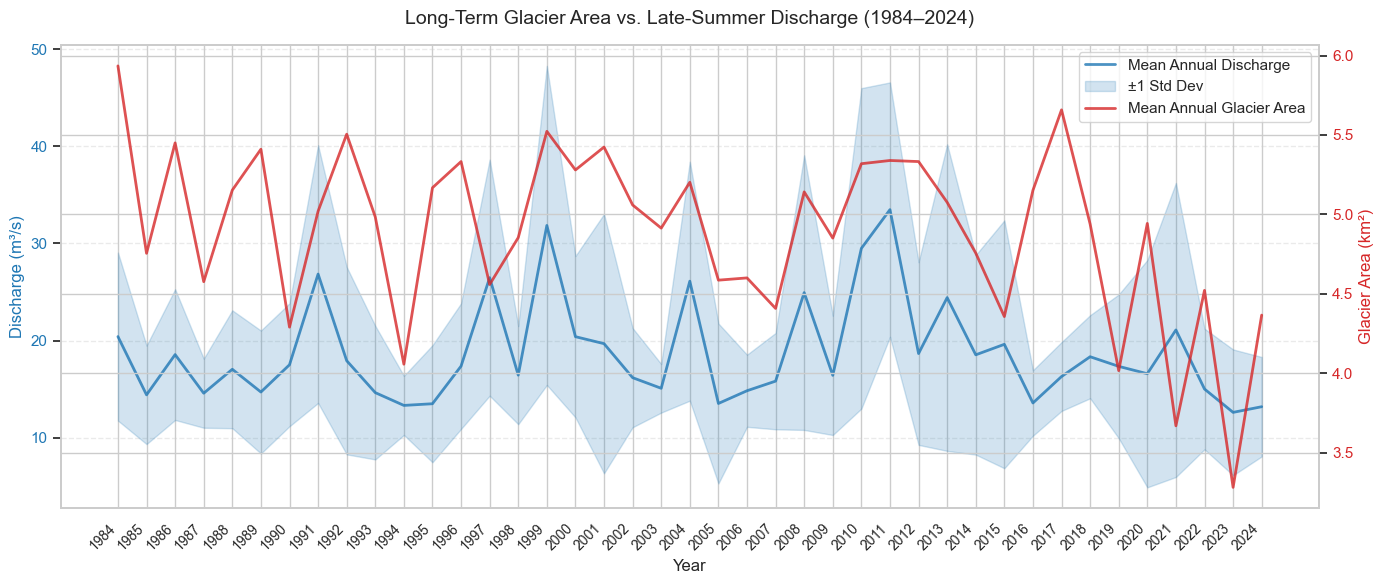

In [13]:
# annual mean and std for discharge
annual_stats = df.groupby('year')['q_cms'].agg(['mean','std'])
annual_glacier = df.groupby('year')['glacier_area_km2'].mean()

fig, ax1 = plt.subplots(figsize=(14,6))

# primary axis: discharge
ax1.plot(annual_stats.index, annual_stats['mean'], color='#1f77b4', lw=2, alpha=0.8, label='Mean Annual Discharge')
ax1.fill_between(annual_stats.index,
                 annual_stats['mean'] - annual_stats['std'],
                 annual_stats['mean'] + annual_stats['std'],
                 color='#1f77b4', alpha=0.2, label='±1 Std Dev')

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Discharge (m³/s)', color='#1f77b4', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax1.set_xticks(annual_stats.index)
ax1.set_xticklabels(annual_stats.index, rotation=45, ha='right', fontsize=10)

# secondary axis: glacier area
ax2 = ax1.twinx()
ax2.plot(annual_glacier.index, annual_glacier.values, color='#d62728', lw=2, alpha=0.8, label='Mean Annual Glacier Area')
ax2.set_ylabel('Glacier Area (km²)', color='#d62728', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#d62728')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')

plt.title('Long-Term Glacier Area vs. Late-Summer Discharge (1984–2024)', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('../figures/05_Glacier_Area_vs_Discharge.png', dpi=300, bbox_inches='tight')
plt.show()

## Climate and Glacier Relationships

### Relationship Analysis (Linear and Non-Linear)
How do features correlate with the target feature `q_cms`

Analysis of linear relationships (Pearson):
- Rolling 7-day discharge (`q_7d_roll_cms`) has the strongest linear correlation with daily discharge (~0.75), as expected.

- Glacier metrics (`glacier_area_km2`, `glacier_5_moving_avg`) show weak linear correlation (~0.17), suggesting linear models may not fully capture their influence.

- Precipitation (`ppt`) shows moderate correlation (~0.39), while temperature and seasonal day are weakly correlated.

Analysis of non-linear relationships (Mutual Information):
- `q_7d_roll_cms` again is the most informative predictor.

- Year and seasonal day show some non-linear information (~0.25–0.27), indicating subtle temporal patterns.

- Glacier area has slightly higher MI (~0.21) than Pearson, showing that non-linear effects matter.

- Precipitation and temperature have relatively low MI, suggesting that in late-summer melt-season, discharge is more strongly controlled by previous flow and glacier extent than by single-day meteorology.

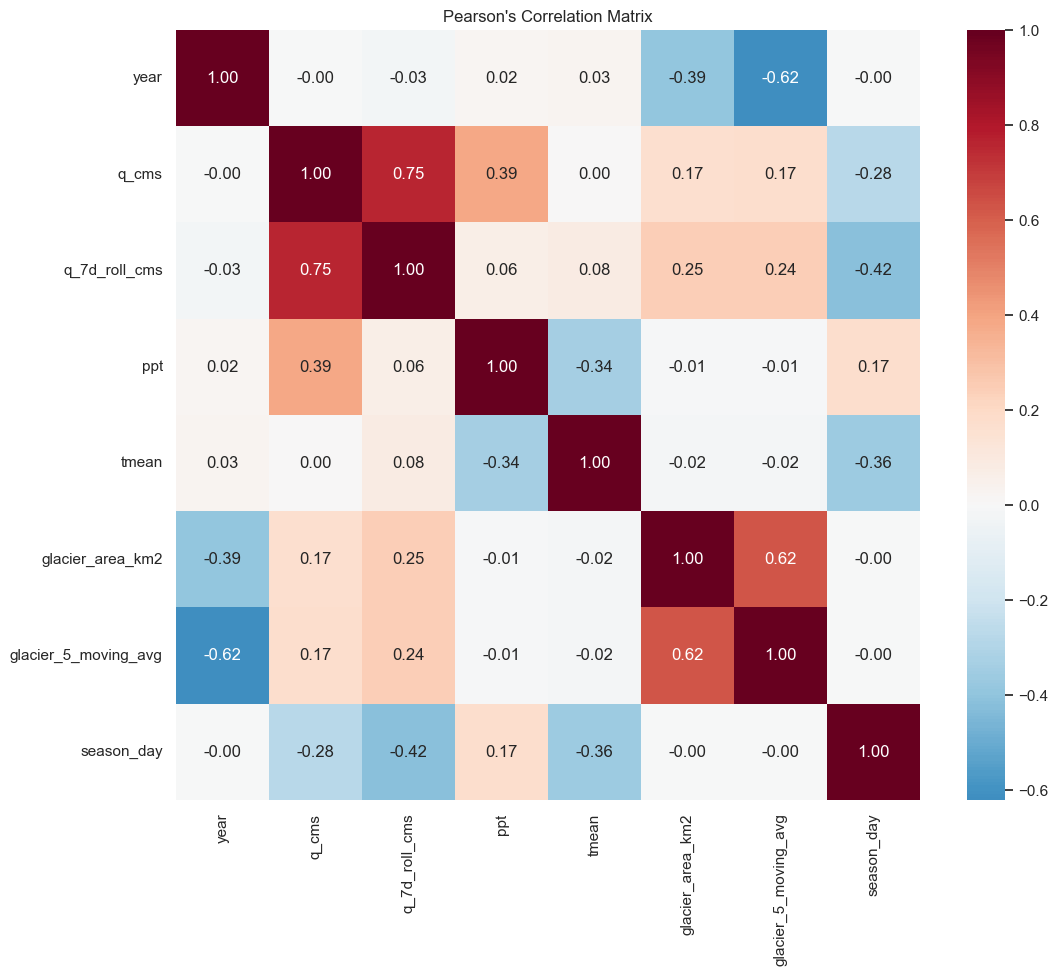

In [14]:
# plot Pearson's correlation heatmap (linear)

# drop non-numeric columns
df_numeric = df.drop(columns=['date','doy','date_label','plot_index'], errors='ignore')

# plot
plt.figure(figsize=(12, 10))
sns.heatmap(df_numeric.corr(), annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title("Pearson's Correlation Matrix")
plt.savefig('../figures/06_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

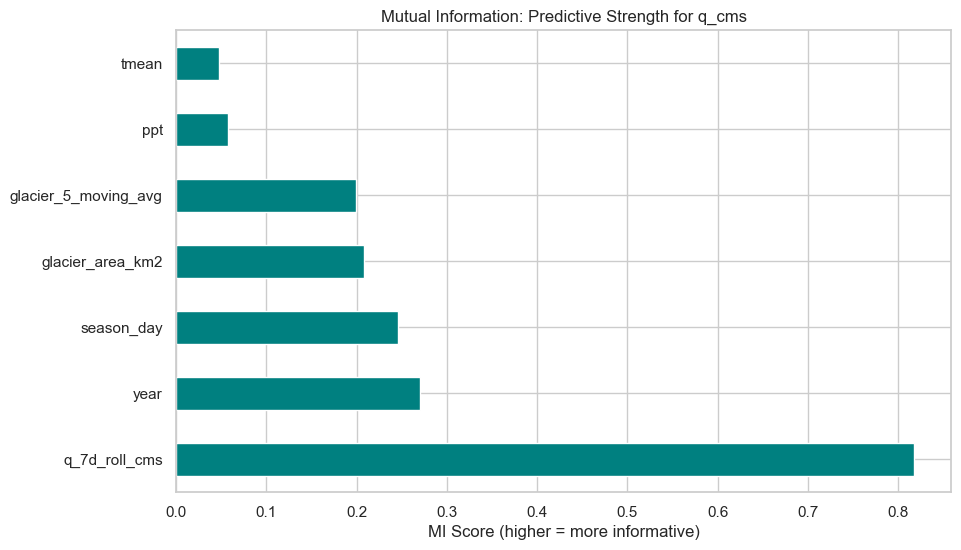

In [15]:
# plot Mutual Information (MI) analysis (non-linear)

# prepare data, drop target feature
X_mi = df_numeric.dropna().drop(columns=['q_cms'])
y_mi = df_numeric.dropna()['q_cms']

# calculate MI
mi_scores = mutual_info_regression(X_mi, y_mi)
mi_results = pd.Series(mi_scores, index=X_mi.columns).sort_values(ascending=False)

# plot
plt.figure(figsize=(10, 6))
mi_results.plot(kind='barh', color='teal')
plt.title('Mutual Information: Predictive Strength for q_cms')
plt.xlabel('MI Score (higher = more informative)')
plt.show()


In [16]:
# display results
correlations = df_numeric.corr()['q_cms'].drop('q_cms')
mi_scores = pd.Series(mutual_info_regression(X_mi, y_mi), index=X_mi.columns)

# combine into single table
relationship_df = pd.DataFrame({
    'Pearson Correlation': correlations,
    'Mutual Info Score': mi_scores
}).sort_values(by='Mutual Info Score', ascending=False)

display(relationship_df.style.background_gradient(cmap='YlGnBu'))

,Pearson Correlation,Mutual Info Score
q_7d_roll_cms,0.754985,0.816731
year,-0.001794,0.272145
season_day,-0.275775,0.242837
glacier_area_km2,0.170397,0.209468
glacier_5_moving_avg,0.173225,0.197125
ppt,0.391855,0.057189
tmean,0.003794,0.047539


### Multicollinearity Assessment

Check whether predictors are highly correlated, which can destabilize linear regression coefficients. Variance Inflation Factor (VIF) quantifies how much a feature’s variance is inflated by correlation with other features.

Analysis:
- `glacier_5_moving_avg` (VIF ~342) and `glacier_area_km2` (VIF ~137) show very high multicollinearity.

- `year` (VIF ~205) is also highly correlated with glacier metrics due to long-term glacier retreat trends.

- `tmean` (VIF ~4.7) and `ppt` (VIF ~1.3) are acceptable and can safely remain in the model.

Implications for modeling:
- To avoid unstable regression coefficients, `glacier_5_moving_avg` and `year` will be dropped from the linear model.

In [17]:
# features to check
features= ['tmean', 'ppt', 'glacier_area_km2', 'glacier_5_moving_avg', 'year']
X_vif = df_numeric[features].dropna()

# calculate VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

# add an interpretation column
vif_data["Status"] = vif_data["VIF"].apply(lambda x: "High" if x > 10 else "Acceptable")

display(vif_data.sort_values(by="VIF", ascending=False))

,feature,VIF,Status
3,glacier_5_moving_avg,342.461986,High
4,year,205.043601,High
2,glacier_area_km2,136.502734,High
0,tmean,4.702350,Acceptable
1,ppt,1.278308,Acceptable


### Heteroscedasticity Analysis

Diagnostic plots to help assess whether relationships between climate variables and discharge satisfy the homoscedasticity assumption required for linear regression models.

Analysis:
- Temperature shows a nearly flat relationship with late-summer discharge, with fairly uniform scatter and variance appears balanced. Temperature is a weak predictor of discharge in this period.

- Precipitation shows a strong positive relationship with discharge, with scatter widening at higher precipitation values. This indicates heteroscedasticity where high-precipitation days have more variable flows. Linear regression assumptions may be violated for precipitation unless transformations are applied.

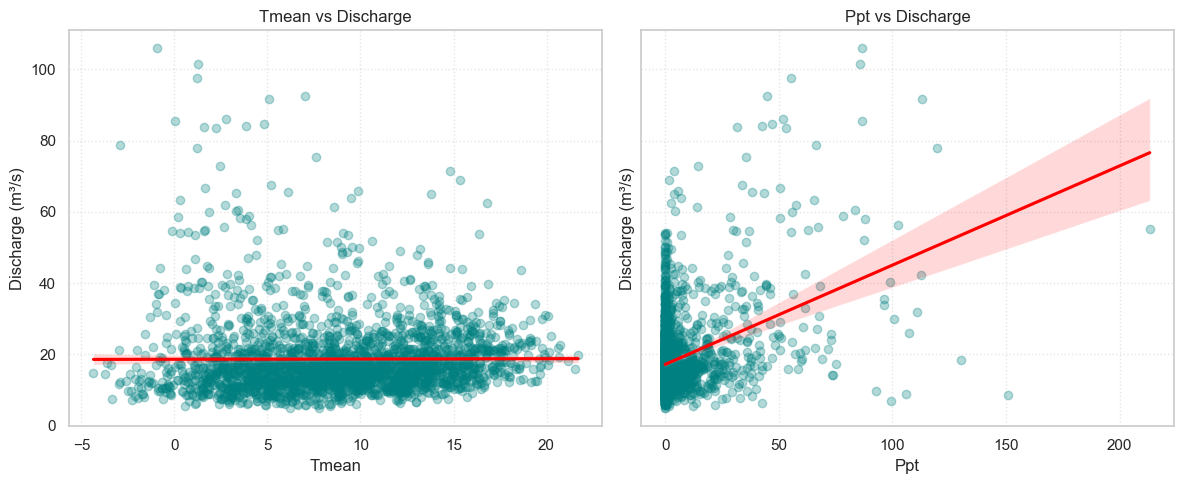

In [18]:
# function to plot heteroscedasticity
def heteroscedasticity_plots(df, predictors, target='q_cms'):
    n = len(predictors)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5), sharey=True)
    
    if n == 1:
        axes = [axes]
    
    for ax, col in zip(axes, predictors):
        sns.regplot(
            data=df, x=col, y=target,
            scatter_kws={'alpha':0.3, 'color':'teal'},
            line_kws={'color':'red'},
            ax=ax
        )
        ax.set_xlabel(col.replace('_', ' ').title())
        ax.set_ylabel('Discharge (m³/s)')
        ax.grid(True, linestyle=':', alpha=0.5)
        ax.set_title(f'{col.replace("_", " ").title()} vs Discharge')
    
    plt.tight_layout()
    plt.show()

# apply function to tmean and ppt
heteroscedasticity_plots(df, predictors=['tmean', 'ppt'])

### Glacier Area vs Discharge

To explore how glacier retreat relates to streamflow variability, discharge is plotted against glacier area. A LOWESS (locally weighted regression) curve is used to visualize potential nonlinear relationships between glacier extent and late-summer discharge.

Analysis:
- The LOWESS line shows a slight positive trend at higher glacier areas, suggesting that larger glacier areas contribute to higher late-summer discharge.

- Glacier retreat has a moderate influence on late-summer streamflow, but other factors (precipitation, temperature) also play a significant role.

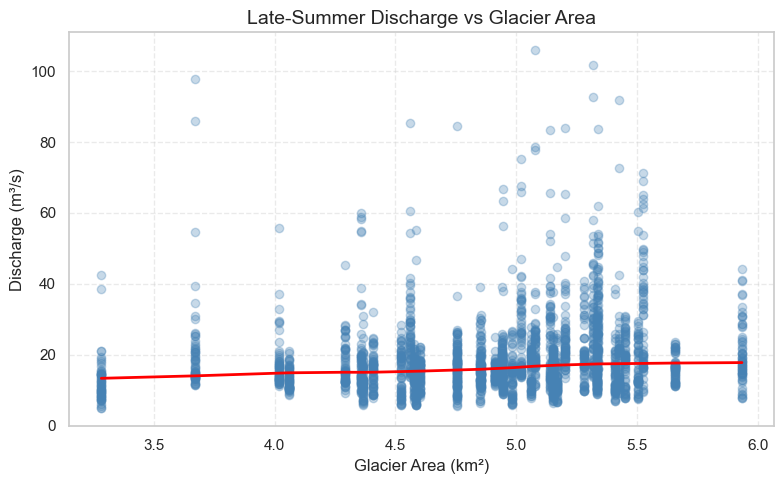

In [19]:
# function to plot glacier area vs discharge m3/s
def plot_glacier_vs_discharge(df):
    plt.figure(figsize=(8,5))
    
    # LOWESS scatter plot
    sns.regplot(
        data=df,
        x='glacier_area_km2',
        y='q_cms',
        lowess=True,
        scatter_kws={'alpha':0.3, 'color':'steelblue'},
        line_kws={'color':'red', 'lw':2}
    )
    
    plt.title('Late-Summer Discharge vs Glacier Area', fontsize=14)
    plt.xlabel('Glacier Area (km²)')
    plt.ylabel('Discharge (m³/s)')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

plot_glacier_vs_discharge(df)

# 3. Feature Engineering

## Log transformations

Log transform the 'q_cms' and 'ppt' features to reduce skewness (right skewed) and stabilize variance

In [20]:
# log1p (log(1+x)) transform q_cms and ppt
df['log_q_cms'] = np.log1p(df['q_cms'])
df['log_ppt'] = np.log1p(df['ppt'])


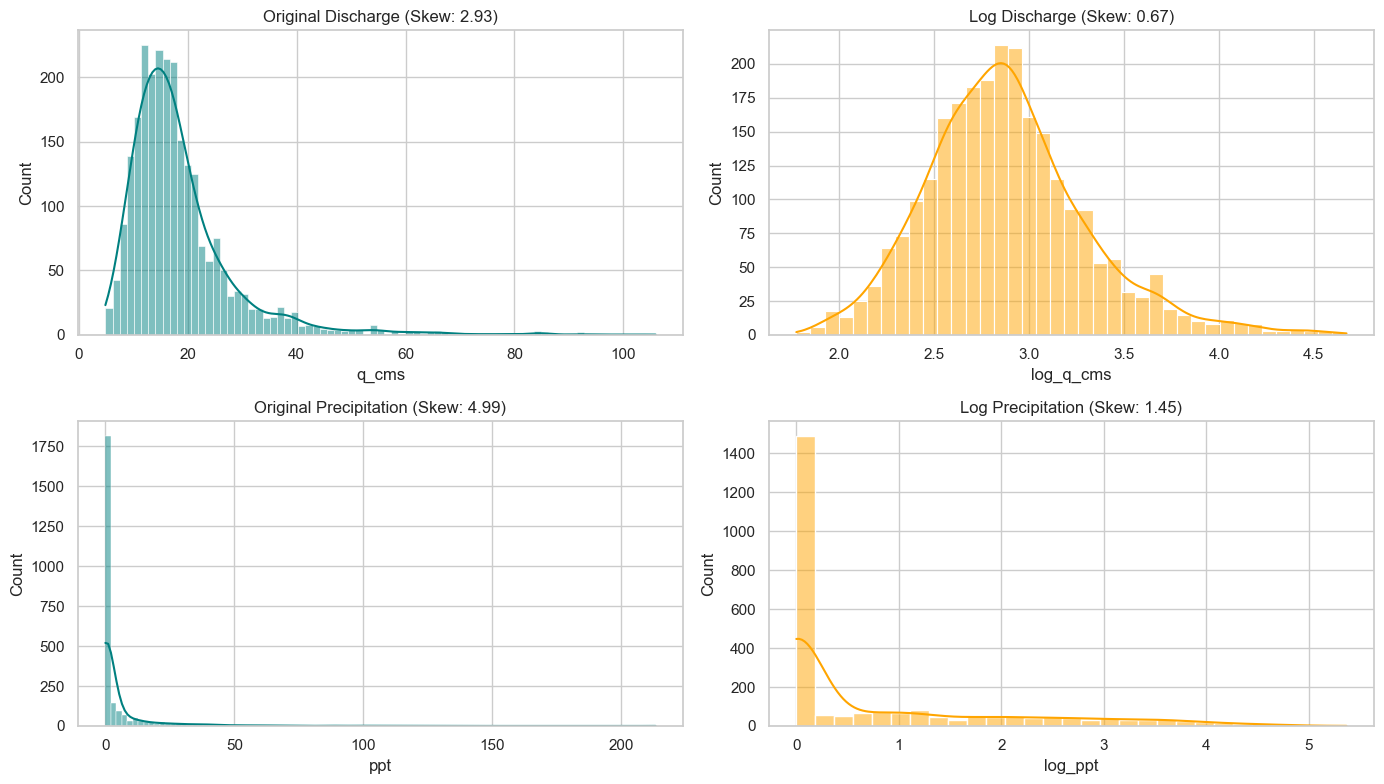

In [21]:
# visualize before and after log transformations
vars_to_log = [('q_cms', 'log_q_cms', 'Discharge'), ('ppt', 'log_ppt', 'Precipitation')]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, (orig, log, name) in enumerate(vars_to_log):
    sns.histplot(df[orig], kde=True, ax=axes[i, 0], color='teal')
    axes[i, 0].set_title(f'Original {name} (Skew: {df[orig].skew():.2f})')
    
    sns.histplot(df[log], kde=True, ax=axes[i, 1], color='orange')
    axes[i, 1].set_title(f'Log {name} (Skew: {df[log].skew():.2f})')

plt.tight_layout()

## Lagged Feature Selection

Partial Autocorrelation Function (PACF): How much does yesterday's streamflow predict today's streamflow?
- Created 1-day lag for 'q_cms'

Cross-Correlation Function (CCF): What is the delay between an event (for example, a hot day or rainfall) and an effect (streamflow)?
- Created 1-2 day lags for 'log_ppt'
- Created 1-3 day lags for 'tmean'


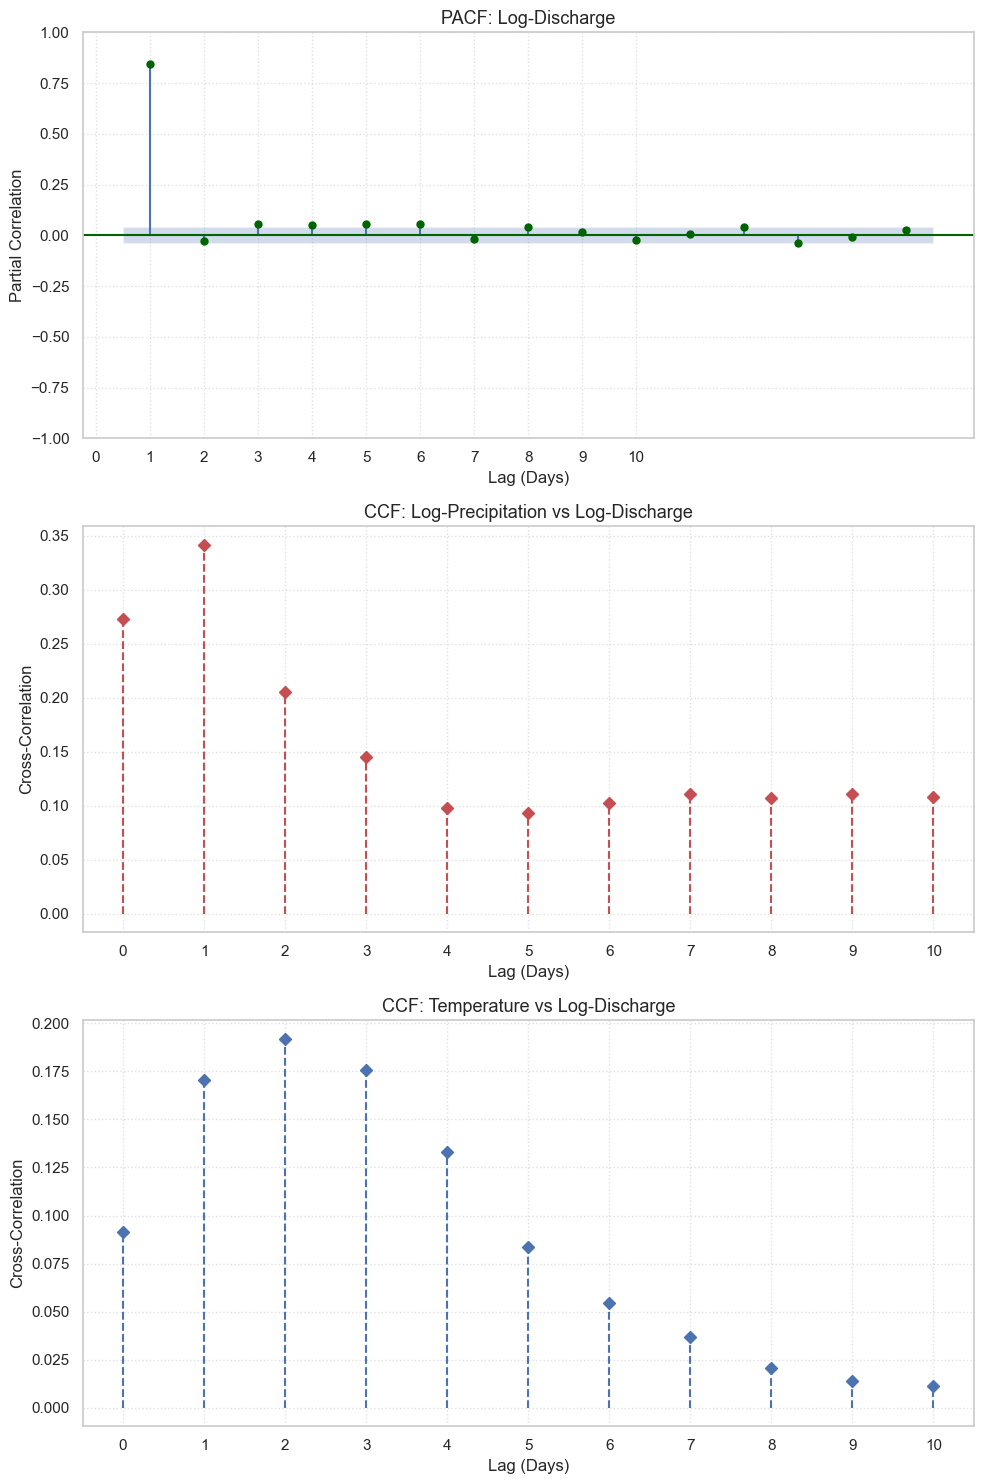

In [22]:
# plot PACF and CCF
y_log = df['log_q_cms'].dropna()
x_log_ppt = df['log_ppt'].dropna()

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# PACF
plot_pacf(y_log, lags=15, ax=axes[0], method='ywm', 
          color='darkgreen', zero=False)
axes[0].set_title('PACF: Log-Discharge', fontsize=13)
axes[0].set_ylabel('Partial Correlation')

# CCF precipitation
lags_range = range(0, 11)
ppt_ccf = [y_log.corr(x_log_ppt.shift(i)) for i in lags_range]
axes[1].stem(lags_range, ppt_ccf, linefmt='--r', markerfmt='Dr', basefmt=" ")
axes[1].set_title('CCF: Log-Precipitation vs Log-Discharge', fontsize=13)
axes[1].set_ylabel('Cross-Correlation')

# CCF temperature
tmean_ccf = [y_log.corr(df['tmean'].shift(i)) for i in lags_range]
axes[2].stem(lags_range, tmean_ccf, linefmt='--b', markerfmt='Db', basefmt=" ")
axes[2].set_title('CCF: Temperature vs Log-Discharge', fontsize=13)
axes[2].set_ylabel('Cross-Correlation')

for ax in axes:
    ax.set_xlabel('Lag (Days)')
    ax.set_xticks(range(0, 11))
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [23]:
# create modeling dataset
df_model = df[['date','year','log_q_cms','log_ppt','tmean','glacier_area_km2']].copy()

# set datetime index
df_model['date'] = pd.to_datetime(df_model['date'])
df_model = df_model.set_index('date')

# create lagged features
# precipitation lags
for lag in [1,2]:
    df_model[f'log_ppt_lag{lag}'] = df_model['log_ppt'].shift(lag)

# temperature lags
for lag in [1,2,3]:
    df_model[f'tmean_lag{lag}'] = df_model['tmean'].shift(lag)

# hydrologic memory
df_model['log_q_lag1'] = df_model['log_q_cms'].shift(1)

# remove rows created by lagging
df_model = df_model.dropna()

### Final Model Multicollinearity Assesment

Analysis: 
- VIF analysis for the final model features show that many of the features are highly correlated with other predictors.

- This is to be expected for the lag features as they are naturally autocorrelated and the features are retained for their physical significance.

- Will drop `year` from the modeling predictors as it has the highest VIF value

In [24]:
model_features_to_check = df_model.drop(columns=['log_q_cms'])

# calculate VIF
vif_model_data = pd.DataFrame()
vif_model_data["feature"] = model_features_to_check.columns
vif_model_data["VIF"] = [variance_inflation_factor(model_features_to_check.values, i) for i in range(len(model_features_to_check.columns))]

# add an interpretation column
vif_model_data["Status"] = vif_model_data["VIF"].apply(lambda x: "High" if x > 10 else "Acceptable")

display(vif_model_data.sort_values(by="VIF", ascending=False))

,feature,VIF,Status
0,year,109.239319,High
3,glacier_area_km2,86.862171,High
9,log_q_lag1,72.938514,High
7,tmean_lag2,27.353310,High
6,tmean_lag1,27.330217,High
2,tmean,14.907085,High
8,tmean_lag3,12.277408,High
5,log_ppt_lag2,2.782262,Acceptable
4,log_ppt_lag1,2.665578,Acceptable
1,log_ppt,2.183273,Acceptable


## Final Modeling Feature Sets

Two feature configurations are constructed to evaluate how glacier information and hydrological memory influence streamflow prediction.

### Configuration A: Full Feature Set
This configuration includes glacier area, climate variables, and lagged hydrological variables. It represents the physically informed model, capturing both climatic forcing and glacier retreat dynamics.

Features:
- Glacier area (km²)
- Mean temperature
- Precipitation (log-transformed)
- Temperature lags (1–3 days)
- Precipitation lags (1–2 days)
- Previous day discharge (log-transformed)

### Configuration B: Reduced Feature Set
This configuration removes lagged hydrological and climate memory features to test whether long-term glacier retreat alone can explain discharge variability.

Features:
- Glacier area (km²)
- Mean temperature
- Precipitation (log-transformed)

Comparing these configurations allows assessment of how short-term hydrological memory vs long-term glacier retreat contributes to streamflow prediction skill.

In [25]:
# full feature configuration (config A)
features_A = [
    'log_ppt',
    'log_ppt_lag1',
    'log_ppt_lag2',
    'tmean',
    'tmean_lag1',
    'tmean_lag2',
    'tmean_lag3',
    'log_q_lag1',
    'glacier_area_km2'
]

# reduced feature configuration (config B)
lag_features = [
    'log_q_lag1',
    'log_ppt_lag1',
    'log_ppt_lag2',
    'tmean_lag1',
    'tmean_lag2',
    'tmean_lag3'
]

features_B = [f for f in features_A if f not in lag_features]

print("Config A Features:", features_A)
print("\nConfig B Features:", features_B)

Config A Features: ['log_ppt', 'log_ppt_lag1', 'log_ppt_lag2', 'tmean', 'tmean_lag1', 'tmean_lag2', 'tmean_lag3', 'log_q_lag1', 'glacier_area_km2']

Config B Features: ['log_ppt', 'tmean', 'glacier_area_km2']


In [26]:
print("Final modeling dataset shape:", df_model.shape)
df_model.head()

Final modeling dataset shape: (2498, 11)


,year,log_q_cms,log_ppt,tmean,glacier_area_km2,log_ppt_lag1,log_ppt_lag2,tmean_lag1,tmean_lag2,tmean_lag3,log_q_lag1
date,,,,,,,,,,,
1984-08-04,1984,3.452592,1.426198,11.965207,5.934645,2.287207,0.854190,10.882959,11.771050,12.659654,3.538458
1984-08-05,1984,3.461518,1.054419,8.693347,5.934645,1.426198,2.287207,11.965207,10.882959,11.771050,3.452592
1984-08-06,1984,3.387773,0.000000,6.904562,5.934645,1.054419,1.426198,8.693347,11.965207,10.882959,3.461518
1984-08-07,1984,3.261502,0.000000,11.540183,5.934645,0.000000,1.054419,6.904562,8.693347,11.965207,3.387773
1984-08-08,1984,3.371377,0.000000,16.024183,5.934645,0.000000,0.000000,11.540183,6.904562,8.693347,3.261502


# 4. Model Development

## Data Preparation

In [38]:
X_train_A, X_test_A, y_train_A, y_test_A, scaler_A = prepare_data(df_model, features_A)
X_train_B, X_test_B, y_train_B, y_test_B, scaler_B = prepare_data(df_model, features_B)

In [39]:
# explore train and test data

# check years in train and test data
# map split indices back to the 'year' column in df
train_years_actual = y_train_A.index.year
test_years_actual = y_test_A.index.year

unique_train = sorted(train_years_actual.unique())
unique_test = sorted(test_years_actual.unique())

# train years
print(f"Training years: {min(unique_train)} to {max(unique_train)}")

# test years
print(f"Testing years: {min(unique_test)} to {max(unique_test)}")

# config A
print('\nConfig A:')
print('Training data shape: ', X_train_A.shape)
print('Testing data shape: ', X_test_A.shape)

# config B
print('\nConfig B:')
print('Training data shape: ', X_train_B.shape)
print('Testing data shape: ', X_test_B.shape)

Training years: 1984 to 2016
Testing years: 2016 to 2024

Config A:
Training data shape:  (1998, 9)
Testing data shape:  (500, 9)

Config B:
Training data shape:  (1998, 3)
Testing data shape:  (500, 3)


## Model Training

### Multiple Linear Regression

In [40]:
# MLR-A
mlr_A, y_pred_mlr_A, mlr_metrics_A = train_predict_model(
    X_train_A, X_test_A, y_train_A, y_test_A, model_type='MLR'
)

# model performance report
mlr_A_report = get_full_report(mlr_A, X_train_A, y_train_A, X_test_A, y_test_A, "MLR Config A")


MLR Config A Performance Report


,Metric,Train,Test,Difference
0,R2,0.716610,0.536012,0.180598
1,MAE,2.657561,2.364016,0.293545
2,RMSE,5.791168,5.881704,-0.090536
3,NSE,0.716610,0.536012,0.180598
4,KGE,0.776578,0.712515,0.064064
5,PBIAS,-2.237042,0.558345,-2.795387


In [41]:
# MLR-B
mlr_B, y_pred_mlr_B, mlr_metrics_B = train_predict_model(
    X_train_B, X_test_B, y_train_B, y_test_B, model_type=
    'MLR'
)

# model performance report
mlr_B_report = get_full_report(mlr_B, X_train_B, y_train_B, X_test_B, y_test_B, "MLR Config B")


MLR Config B Performance Report


,Metric,Train,Test,Difference
0,R2,0.126430,0.100466,0.025964
1,MAE,6.390124,4.768099,1.622026
2,RMSE,10.167695,8.189519,1.978175
3,NSE,0.126430,0.100466,0.025964
4,KGE,0.080545,0.090865,-0.010320
5,PBIAS,-8.725848,-1.808198,-6.917651


### Random Forest Regression

In [42]:
# RF-A
rf_A = tune_rf_model(X_train_A, y_train_A)

# predict
y_pred_rf_A = np.expm1(rf_A.predict(X_test_A))

# evaluate
rf_metrics_A = evaluate(np.expm1(y_test_A), y_pred_rf_A)

# performance report
rf_A_report = get_full_report(rf_A, X_train_A, y_train_A, X_test_A, y_test_A, "RF Config A")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

RF Config A Performance Report


,Metric,Train,Test,Difference
0,R2,0.901879,0.681594,0.220285
1,MAE,1.498727,2.141095,-0.642369
2,RMSE,3.407643,4.872369,-1.464726
3,NSE,0.901879,0.681594,0.220285
4,KGE,0.826565,0.719205,0.107360
5,PBIAS,-2.206651,1.173645,-3.380296


In [43]:
# RF-B
rf_B = tune_rf_model(X_train_B, y_train_B)

# predict
y_pred_rf_B = np.expm1(rf_B.predict(X_test_B))

# evaluate
rf_metrics_B = evaluate(np.expm1(y_test_B), y_pred_rf_B)

# model performance report
rf_B_report = get_full_report(rf_B, X_train_B, y_train_B, X_test_B, y_test_B, "RF Config B")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

RF Config B Performance Report


,Metric,Train,Test,Difference
0,R2,0.276619,0.274111,0.002508
1,MAE,5.839637,4.688975,1.150662
2,RMSE,9.252458,7.356727,1.895731
3,NSE,0.276619,0.274111,0.002508
4,KGE,0.218554,0.234701,-0.016147
5,PBIAS,-8.883568,4.808908,-13.692477


# 5. Model Evaluation

## Performance Metrics

Analysis:
- Config A (full features) consistently outperforms Config B (reduced features) for both MLR and RF. This highlights the important of lagged features (`log_q_lag1`, `log_ppt_lag1`, `tmean_lag1`, etc.) in capturing the memory effects in streamflow.

- RF generally performs better than MLR, especially for Config A. RF-A has higher R²/NSE (~0.68 vs 0.54), lower RMSE/MAE, and PBIAS close to zero.

- PBIAS values are close to zero across all models, suggesting no systematic over- or underestimation.

- MAE and RMSE show RF-A has the lowest absolute errors (~2.14 MAE, ~4.87 RMSE), indicating better daily discharge prediction.

- Config B models (both MLR and RF) show higher errors due to missing memory effects from lags.

Overfitting assessment:
- RF-A shows a train-test gap of ~0.25 in R²/NSE, indicating some overfitting

- MLR shows less overfitting, but lower test performance (~0.536 NSE), suggesting it underfits the complexity of the system.

- Config B (reduced features) reduces overfitting but sacrifices predictive skill (R² < 0.3).

In [46]:
# compare test performances across all models
comparison_df = pd.DataFrame({
    "Metric": ["R2", "NSE", "KGE", "RMSE", "MAE", "PBIAS"],
    "MLR Config A": [mlr_metrics_A["R2"], mlr_metrics_A["NSE"], mlr_metrics_A["KGE"], mlr_metrics_A["RMSE"], mlr_metrics_A["MAE"], mlr_metrics_A["PBIAS"]],
    "MLR Config B": [mlr_metrics_B["R2"], mlr_metrics_B["NSE"], mlr_metrics_B["KGE"], mlr_metrics_B["RMSE"], mlr_metrics_B["MAE"], mlr_metrics_B["PBIAS"]],
    "RF Config A": [rf_metrics_A["R2"], rf_metrics_A["NSE"], rf_metrics_A["KGE"], rf_metrics_A["RMSE"], rf_metrics_A["MAE"], rf_metrics_A["PBIAS"]],
    "RF Config B": [rf_metrics_B["R2"], rf_metrics_B["NSE"], rf_metrics_B["KGE"], rf_metrics_B["RMSE"], rf_metrics_B["MAE"], rf_metrics_B["PBIAS"]]
})

display(comparison_df.round(3))


,Metric,MLR Config A,MLR Config B,RF Config A,RF Config B
0,R2,0.536,0.100,0.682,0.274
1,NSE,0.536,0.100,0.682,0.274
2,KGE,0.713,0.091,0.719,0.235
3,RMSE,5.882,8.190,4.872,7.357
4,MAE,2.364,4.768,2.141,4.689
5,PBIAS,0.558,-1.808,1.174,4.809


## Feature Importance

MLR Config A:
- `log_q_lag1` is the most influential predictor (0.35), capturing persistence in streamflow.
- `tmean_lag1` and `log_ppt_lag1` have moderate positive influence.
- Glacier area (`glacier_area_km2`) has small positive effect in linear terms.
- Some lags (`tmean_lag2`, `tmean_lag3`, `log_ppt_lag2`) have negative or near-zero influence, reflecting weaker linear effects.

MLR Config B:
- Precipitation (`log_ppt`) and temperature (`tmean`) dominate linear influence.
- Glacier area is minor but still contributes (~0.08).

RF Config A: 
- `log_q_lag1` dominates by far (~0.67), confirming the strong memory effect of previous day discharge.
- `log_ppt_lag1` and `log_ppt` are secondary drivers of variability.
- Glacier area has minor but non-zero contribution.

RF Config B:
- Precipitation (`log_ppt`) and glacier area dominate (~0.41 and 0.35), temperature plays smaller role.
- Removing lagged features reduces the model’s reliance on streamflow memory and emphasizes climate/glacier drivers.

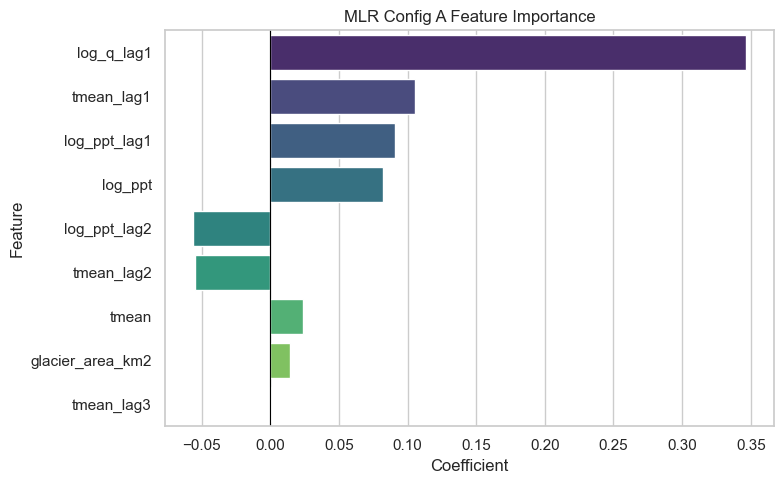

,Feature,Coefficient
7,log_q_lag1,0.346761
4,tmean_lag1,0.105294
1,log_ppt_lag1,0.090589
0,log_ppt,0.081790
2,log_ppt_lag2,-0.056416
5,tmean_lag2,-0.054833
3,tmean,0.024023
8,glacier_area_km2,0.014159
6,tmean_lag3,0.000566


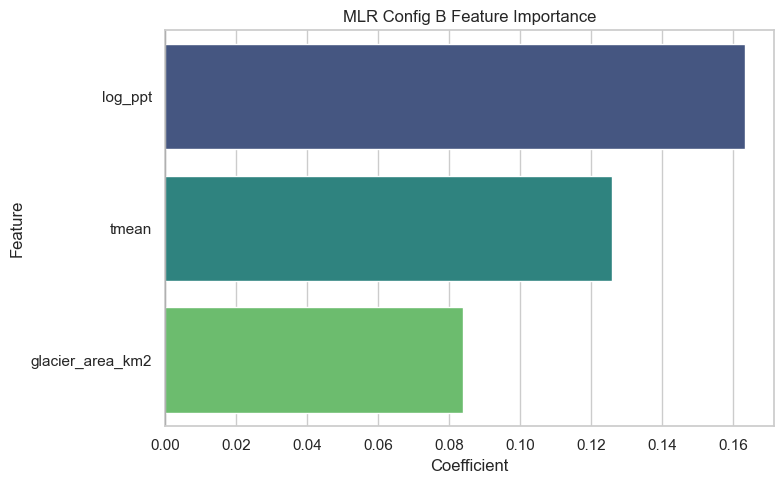

,Feature,Coefficient
0,log_ppt,0.163433
1,tmean,0.125970
2,glacier_area_km2,0.083889


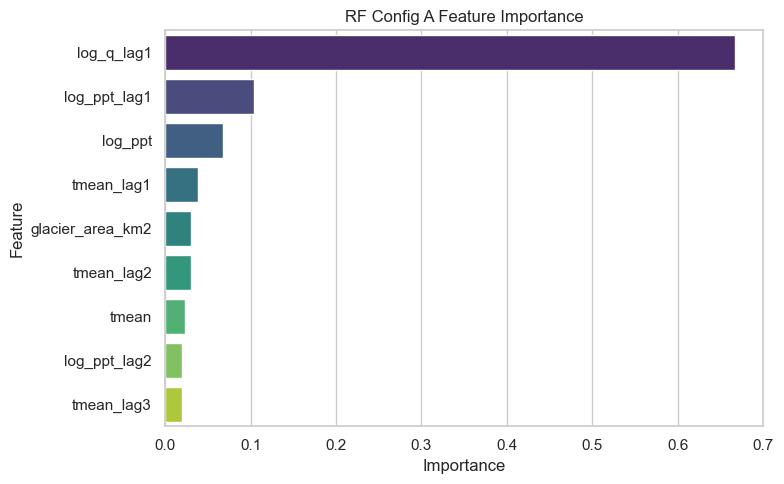

,Feature,Importance
7,log_q_lag1,0.666766
1,log_ppt_lag1,0.104127
0,log_ppt,0.067975
4,tmean_lag1,0.038704
8,glacier_area_km2,0.030218
5,tmean_lag2,0.029924
3,tmean,0.022792
2,log_ppt_lag2,0.019957
6,tmean_lag3,0.019539


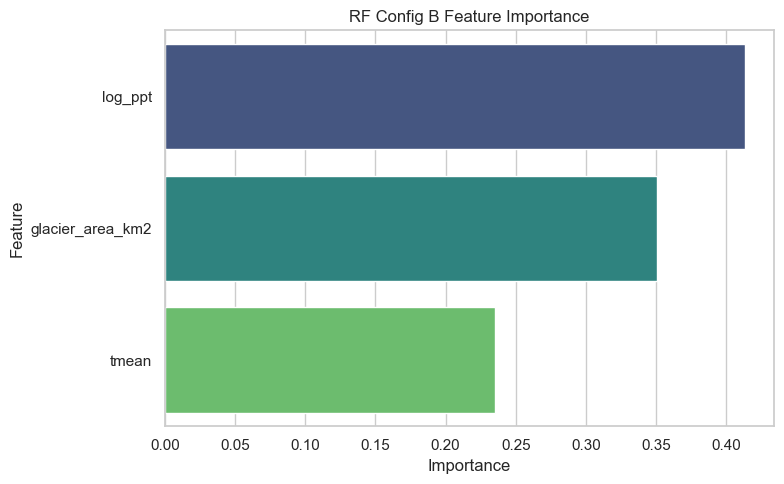

,Feature,Importance
0,log_ppt,0.413523
2,glacier_area_km2,0.350882
1,tmean,0.235595


In [47]:
# functions to plot eature importance for MLR and RF models
def display_mlr_importance(model, X, title):
    """Display and plot MLR coefficients."""
    df_feat = pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": model.coef_
    }).sort_values(by="Coefficient", key=abs, ascending=False) 
    
    plt.figure(figsize=(8,5))
    sns.barplot(
        x='Coefficient',
        y='Feature',
        hue='Feature',
        data=df_feat,
        palette='viridis'
    )
    plt.title(title)
    plt.axvline(0, color='black', lw=0.8)
    plt.tight_layout()
    plt.show()

    display(df_feat.style.background_gradient(cmap='YlGnBu', subset=['Coefficient']))

def display_rf_importance(model, X, title):
    """Display and plot Random Forest feature importance."""
    df_feat = pd.DataFrame({
        "Feature": X.columns,
        "Importance": model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(8,5))
    sns.barplot(
        x='Importance',
        y='Feature',
        hue='Feature',
        data=df_feat,
        palette='viridis'
    )
    plt.title(title)
    legend = False
    plt.tight_layout()
    plt.show()

    display(df_feat.style.background_gradient(cmap='YlGnBu', subset=['Importance']))

models = {
    "MLR Config A": (mlr_A, X_train_A),
    "MLR Config B": (mlr_B, X_train_B),
    "RF Config A": (rf_A, X_train_A),
    "RF Config B": (rf_B, X_train_B)
}

# apply to all models
for name, (model, X) in models.items():
    if "MLR" in name:
        display_mlr_importance(model, X, f"{name} Feature Importance")
    else:
        display_rf_importance(model, X, f"{name} Feature Importance")

## Statistical Significance Test

Analysis of Config A:
- Absolute errors comparison shows:
    - Mean AE: RF = 2.14, MLR = 2.36 m³/s
    - Median AE: RF = 1.07, MLR = 1.05 m³/s
    - Maximum errors are slightly higher for MLR (55 m³/s vs 44 m³/s).
- Wilcoxon signed-rank test: p-value = 0.4389 means that there is no statistically significant difference between RF and MLR.
- Both models capture the bulk of streamflow variability, and the slight edge of RF is not robust.

In [48]:
# absolute errors
errors_mlr = np.abs(np.expm1(y_test_A) - y_pred_mlr_A)
errors_rf = np.abs(np.expm1(y_test_A) - y_pred_rf_A)

# Wilcoxon Signed-Rank test
stat, p_value = wilcoxon(errors_mlr, errors_rf)

# display errors summary
errors_df = pd.DataFrame({
    "MLR Absolute Error": errors_mlr,
    "RF Absolute Error": errors_rf
})
display(errors_df.describe().round(2))

# results
print("Statistical Significance Test (Config A):")
print(f"Wilcoxon Statistic: {stat:.0f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: RF performance is statistically significantly better than MLR (p < 0.05).")
else:
    print("Conclusion: RF and MLR performances are not statistically significantly different (p > 0.05).")

,MLR Absolute Error,RF Absolute Error
count,500.00,500.00
mean,2.36,2.14
std,5.39,4.38
min,0.01,0.00
25%,0.47,0.47
50%,1.05,1.07
75%,2.13,2.01
max,55.02,44.68


Statistical Significance Test (Config A):
Wilcoxon Statistic: 60123
P-value: 0.4389
Conclusion: RF and MLR performances are not statistically significantly different (p > 0.05).


## Predicted vs Observed

In [49]:
def plot_model_diagnostics(y_test_A, y_pred_A, y_test_B, y_pred_B, model_name, filename):
    """
    Plots Observed vs Predicted and Residuals for both Config A and Config B
    in a single figure with subplots.
    """
    # Ensure all predictions are Series with proper indices
    y_test_A = pd.Series(np.expm1(y_test_A), index=y_test_A.index)
    y_pred_A = pd.Series(y_pred_A, index=y_test_A.index)
    y_test_B = pd.Series(np.expm1(y_test_B), index=y_test_B.index)
    y_pred_B = pd.Series(y_pred_B, index=y_test_B.index)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Observed vs Predicted - Config A
    sns.scatterplot(x=y_test_A, y=y_pred_A, alpha=0.5, ax=axes[0,0], color='dodgerblue')
    axes[0,0].plot([0, y_test_A.max()], [0, y_test_A.max()], 'r--', lw=2)
    axes[0,0].set_title(f'{model_name} - Config A: Observed vs Predicted')
    axes[0,0].set_xlabel('Observed (m³/s)')
    axes[0,0].set_ylabel('Predicted (m³/s)')
    axes[0,0].grid(alpha=0.3)

    # Residuals - Config A
    residuals_A = y_test_A - y_pred_A
    axes[1,0].scatter(y_pred_A, residuals_A, alpha=0.5, color='teal')
    axes[1,0].axhline(0, color='r', linestyle='--', lw=2)
    axes[1,0].set_title(f'{model_name} - Config A: Residuals')
    axes[1,0].set_xlabel('Predicted (m³/s)')
    axes[1,0].set_ylabel('Residuals (Observed - Predicted)')
    axes[1,0].grid(alpha=0.3)

    # Observed vs Predicted - Config B
    sns.scatterplot(x=y_test_B, y=y_pred_B, alpha=0.5, ax=axes[0,1], color='orange')
    axes[0,1].plot([0, y_test_B.max()], [0, y_test_B.max()], 'r--', lw=2)
    axes[0,1].set_title(f'{model_name} - Config B: Observed vs Predicted')
    axes[0,1].set_xlabel('Observed (m³/s)')
    axes[0,1].set_ylabel('Predicted (m³/s)')
    axes[0,1].grid(alpha=0.3)

    # Residuals - Config B
    residuals_B = y_test_B - y_pred_B
    axes[1,1].scatter(y_pred_B, residuals_B, alpha=0.5, color='green')
    axes[1,1].axhline(0, color='r', linestyle='--', lw=2)
    axes[1,1].set_title(f'{model_name} - Config B: Residuals')
    axes[1,1].set_xlabel('Predicted (m³/s)')
    axes[1,1].set_ylabel('Residuals (Observed - Predicted)')
    axes[1,1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'../figures/{filename}', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

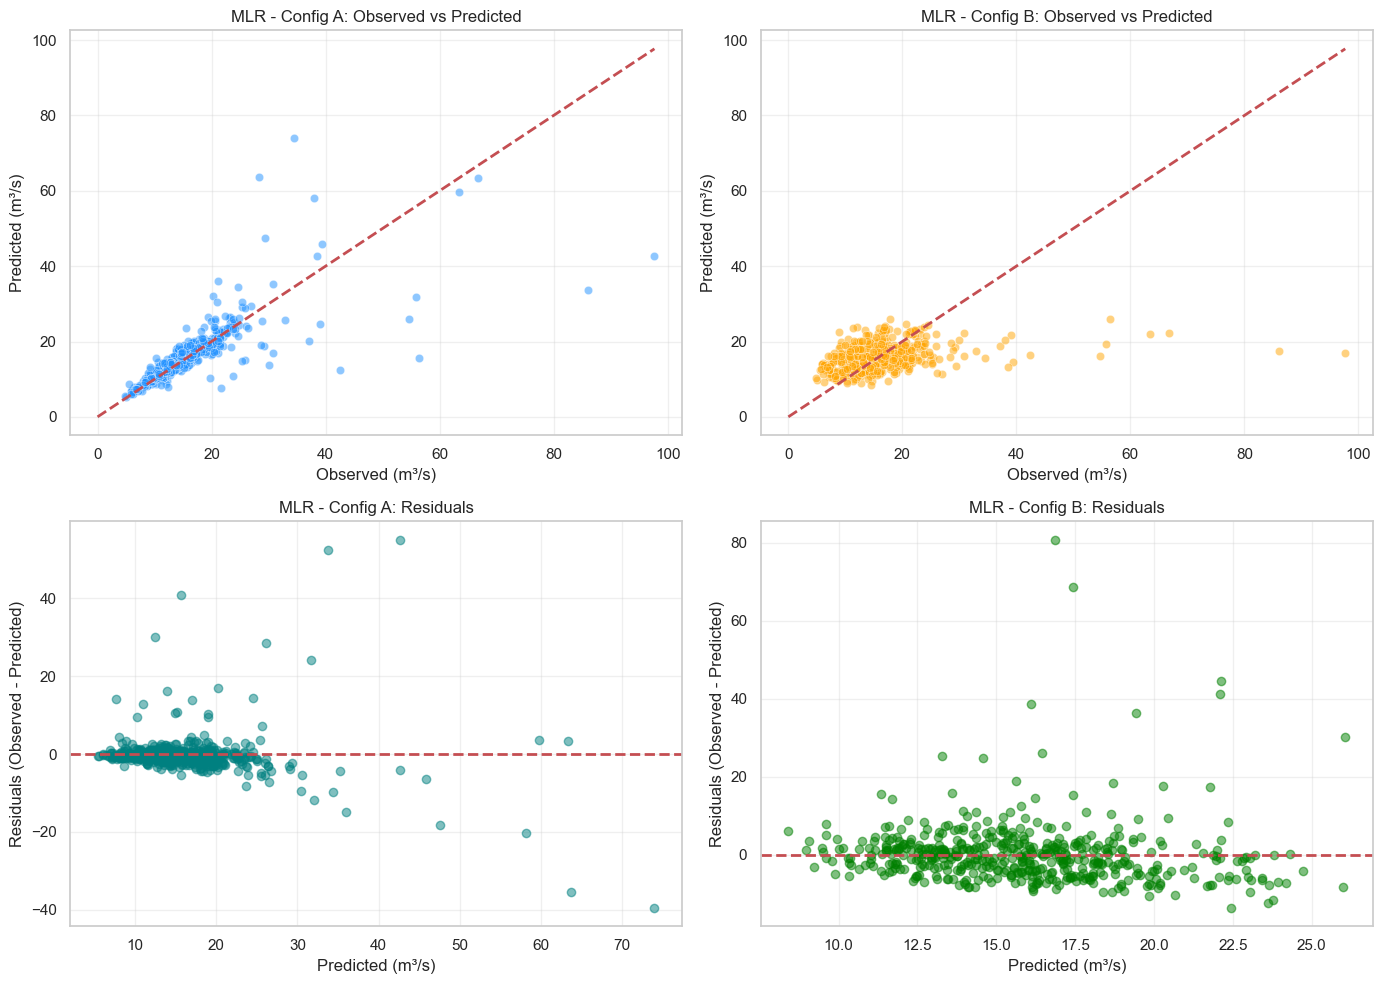

In [50]:
# plot MLR diagnostics
plot_model_diagnostics(
    y_test_A=y_test_A,
    y_pred_A=y_pred_mlr_A,
    y_test_B=y_test_B,
    y_pred_B=y_pred_mlr_B,
    model_name='MLR',
    filename='07_MLR_diagnostics.png'
)

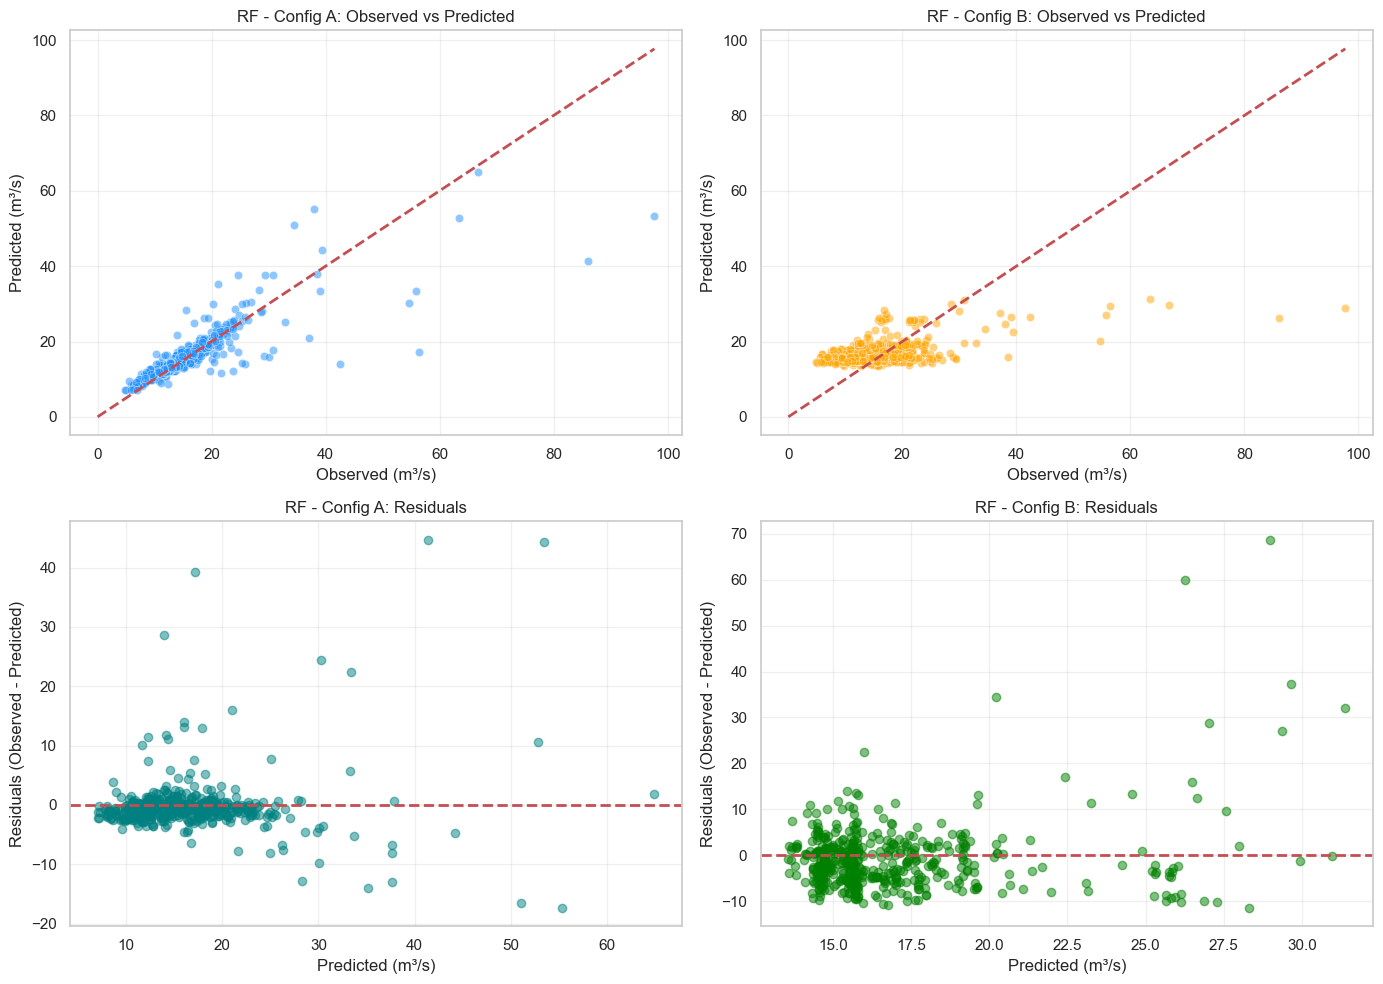

In [56]:
# plot RF diagnostics
plot_model_diagnostics(
    y_test_A=y_test_A,
    y_pred_A=y_pred_rf_A,
    y_test_B=y_test_B,
    y_pred_B=y_pred_rf_B,
    model_name='RF',
    filename='08_RF_diagnostics.png'
)

## Comparative Hydrographs

In [52]:
def plot_comparative_hydrographs(y_test, models_dict, config_name, filename=None):
    # ensure y_test has a DatetimeIndex
    y_test = y_test.copy()
    y_test.index = pd.to_datetime(y_test.index)

    years = pd.to_datetime(y_test.index).year.unique()
    fig, axes = plt.subplots(len(years), 1, figsize=(12, 3 * len(years)), sharey=True)
    if len(years) == 1: axes = [axes]

    colors = ['dodgerblue', 'orange', 'green', 'purple']

    for ax, year in zip(axes, years):
        ax.set_xlim(pd.Timestamp(f'{year}-08-01'), pd.Timestamp(f'{year}-09-30'))

        # plot observed
        obs_y = y_test[y_test.index.year == year]
        ax.plot(obs_y.index, obs_y.values, color='black', lw=2, label='Observed', zorder=3)

        # plot models
        for i, (name, y_pred_series) in enumerate(models_dict.items()):
            y_pred_series.index = pd.to_datetime(y_pred_series.index)
            pred_y = y_pred_series[y_pred_series.index.year == year]
            ax.plot(pred_y.index, pred_y.values, color=colors[i], ls='--', label=name)

        ax.set_xlim(pd.Timestamp(f'{year}-08-01'), pd.Timestamp(f'{year}-09-30'))
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=15))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        ax.set_title(f'{config_name} ({year})')
        ax.set_ylabel('m³/s')
        ax.legend(loc='upper right', fontsize='small')
        ax.grid(alpha=0.3)

    plt.tight_layout()
    
    if filename:
        save_path = f'../figures/{filename}'
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Figure saved to: {save_path}")
    
    plt.show()

y_test_A_real = pd.Series(np.expm1(y_test_A), index=y_test_A.index)
y_test_B_real = pd.Series(np.expm1(y_test_B), index=y_test_B.index)

Figure saved to: ../figures/09_hydrograph_comparison_ConfigA.png


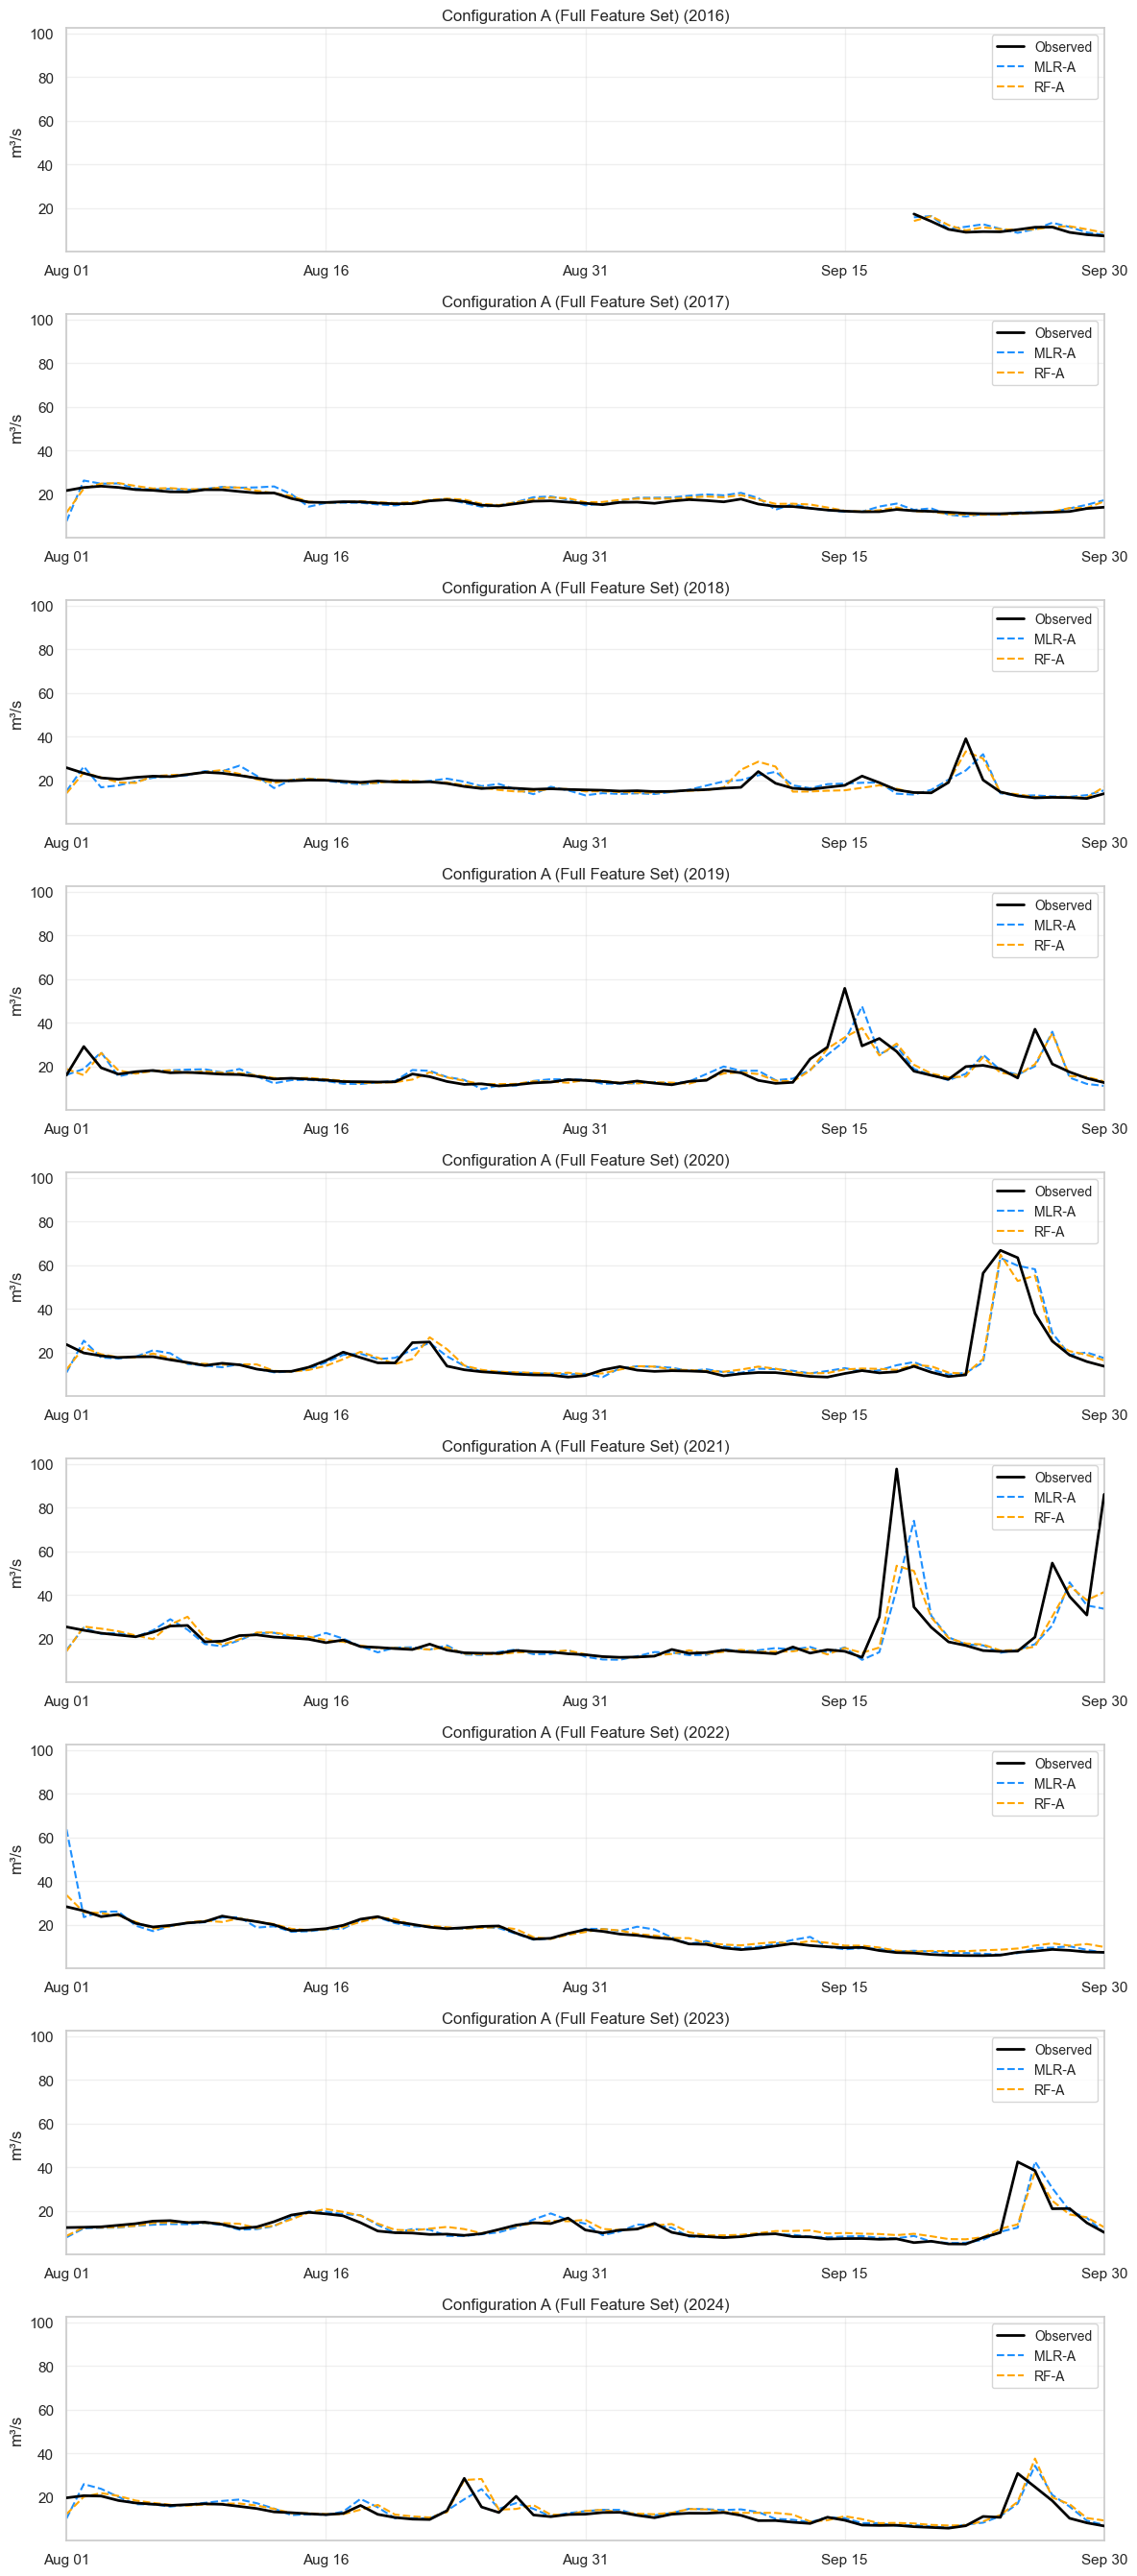

In [53]:
# config A
config_A_models = {
    'MLR-A': pd.Series(y_pred_mlr_A, index=y_test_A.index),
    'RF-A': pd.Series(y_pred_rf_A, index=y_test_A.index)
}

plot_comparative_hydrographs(y_test_A_real, 
                             config_A_models, 
                             'Configuration A (Full Feature Set)',
                             filename='09_hydrograph_comparison_ConfigA.png')

Figure saved to: ../figures/10_hydrograph_comparison_ConfigB.png


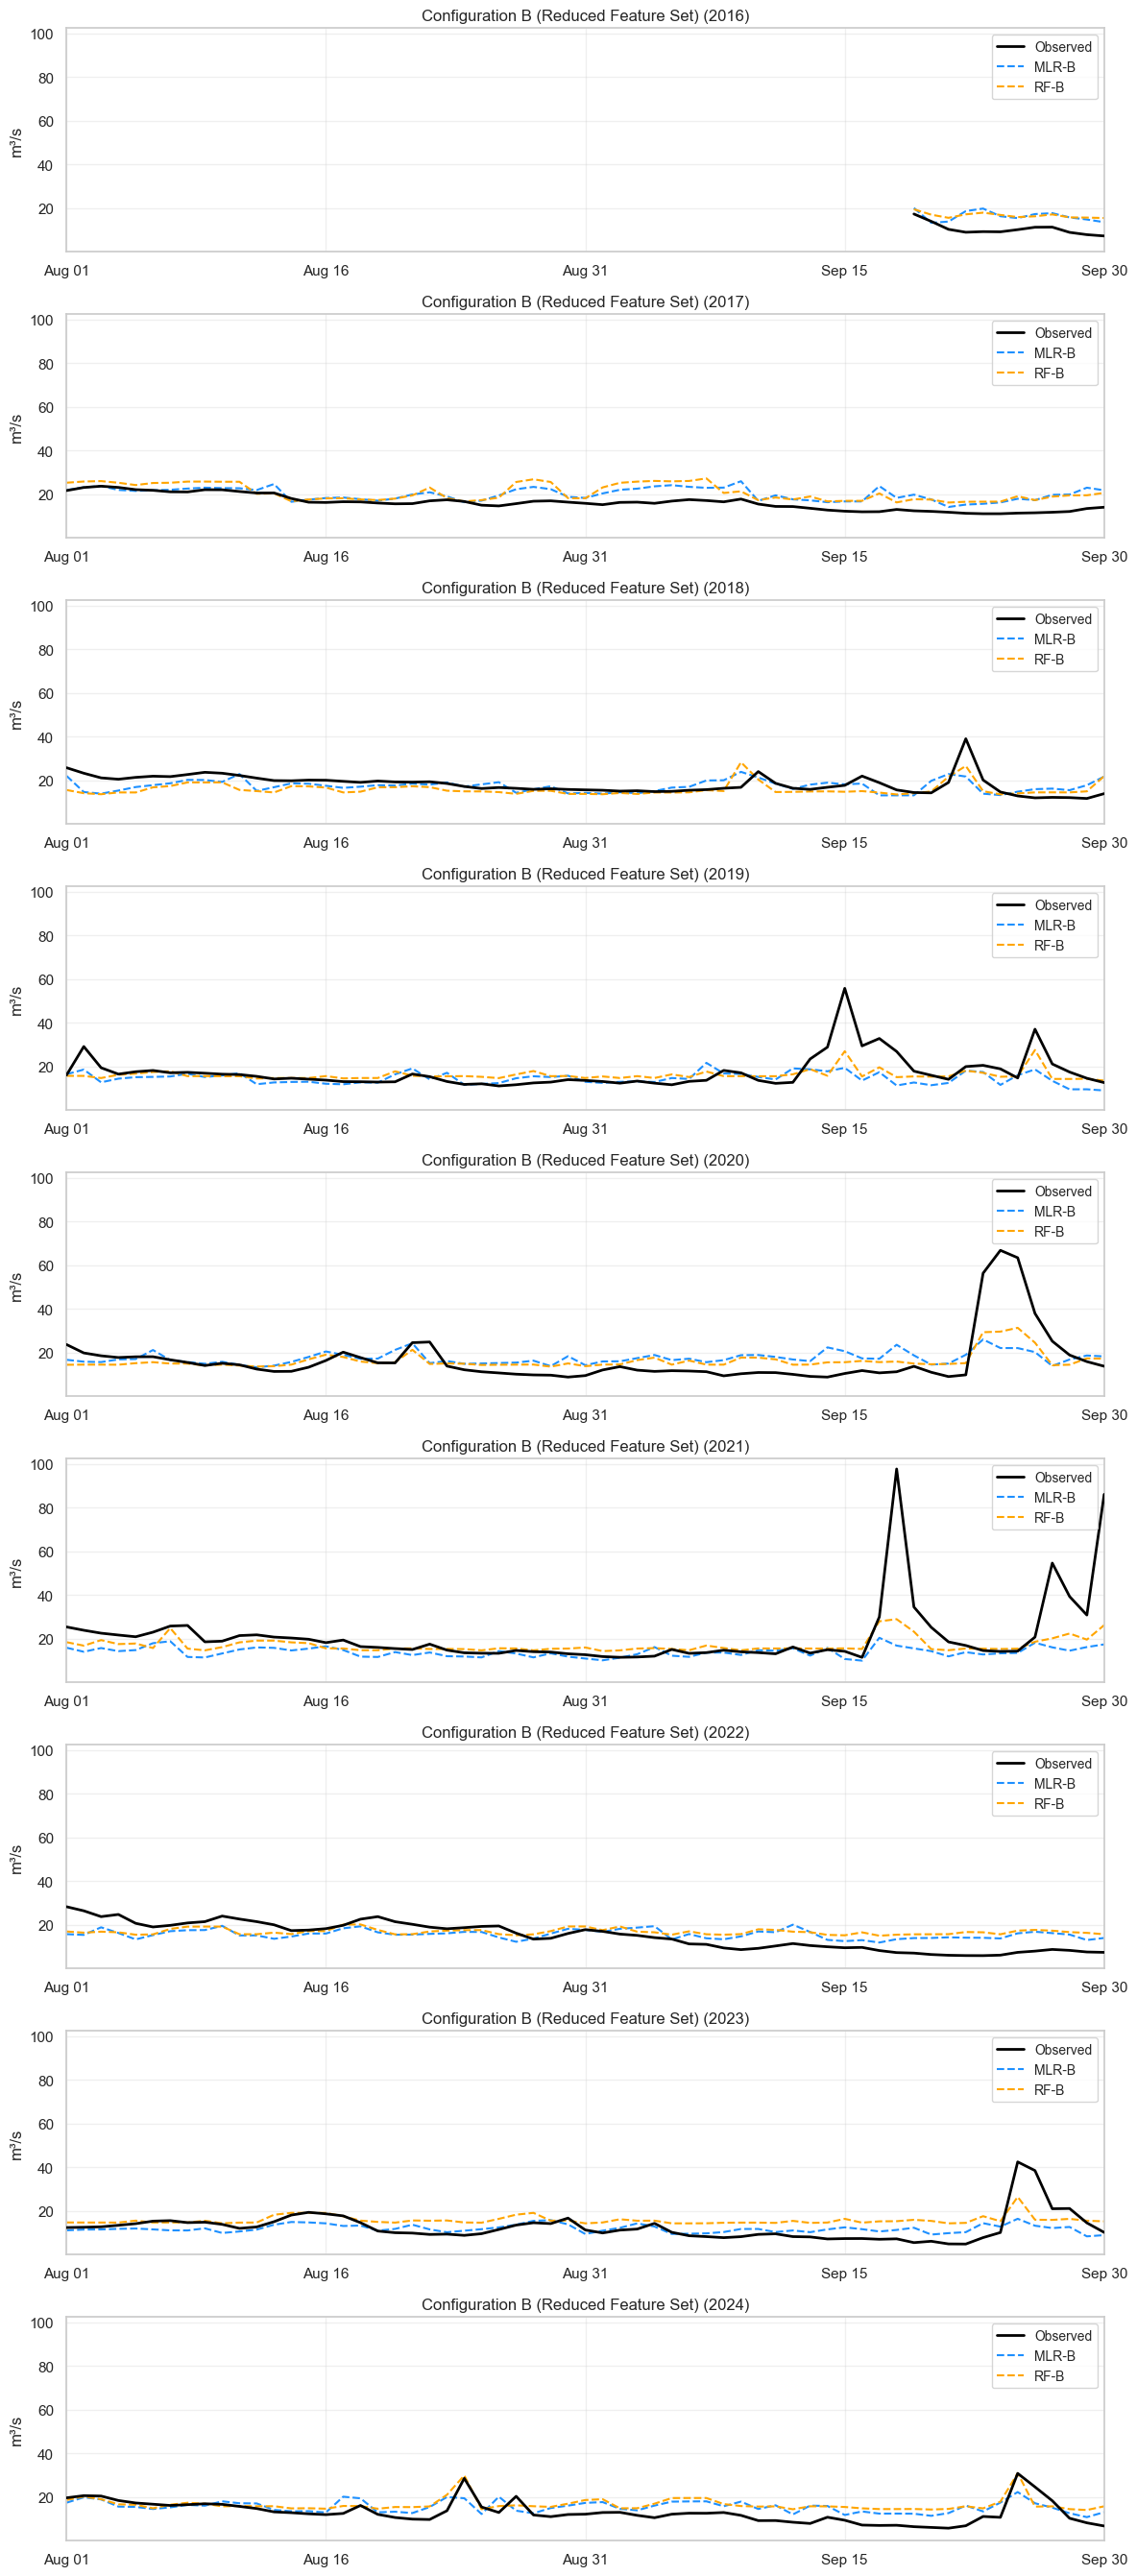

In [55]:
# config B
config_B_models = {
    'MLR-B': pd.Series(y_pred_mlr_B, index=y_test_B.index),
    'RF-B': pd.Series(y_pred_rf_B, index=y_test_B.index)
}
plot_comparative_hydrographs(y_test_B_real, 
                             config_B_models, 
                             'Configuration B (Reduced Feature Set)',
                             filename='10_hydrograph_comparison_ConfigB.png')

# Key Findings
- The most significant finding was the impact of Lagged Features (Configuration A). Across all model types, the inclusion of the previous day’s discharge (`log_q_lag1`) and lagged climate variables improved the Nash-Sutcliffe Efficiency (NSE) from ~0.10 to ~0.68.

- Late-summer streamflow in the Nooksack River is highly persistent. Today’s flow is the strongest predictor of tomorrow’s flow, reflecting the slow drainage of the basin's "storage" (groundwater and glacial meltwater).

- While the Random Forest model achieved the best overall metrics (NSE = 0.68), the Wilcoxon Signed-Rank Test revealed that the difference between RF and the Multiple Linear Regression baseline was not statistically significant (p = 0.43).

- In the reduced-features model (Config B), where daily memory was removed, Glacier Area emerged as a primary driver of variability (Feature Importance ~35%).

- Diagnostic plots showed that both models exhibit heteroscedasticity. They are highly accurate at predicting baseflow but struggle with extreme high-magnitude events.

## Future Recommendations
To build on this work, future iterations could:

- Add SNOTEL Snow Water Equivalent (SWE) data which could improve the transition from spring freshet to late-summer baseflow.

- Implement a weighted loss function (e.g., focusing on high-flow RMSE) to better capture rare flood events.

- Apply the trained Random Forest model to future climate scenarios (CMIP6) to quantify potential streamflow loss by 2050.